# 00. 데이터 확인

In [1]:
import pandas as pd

data = pd.read_csv("../data/final/final_human_ai_100k.csv")

In [3]:
data['source'].value_counts()

source
human    50000
ai       50000
Name: count, dtype: int64

In [5]:
data[data['source']=='human']['topic_code'].value_counts()

topic_code
320    10000
360    10000
370    10000
400    10000
440    10000
Name: count, dtype: int64

In [6]:
data

,text,word_count,length_bin,topic_code,topic_name,source
0,그러면서 기술과 자본이 어우러져 만들어내는 생산력이 19세기 패권 경쟁에서 가장 중...,13,10-14,320,경제학,human
1,그렇다면 차를 살 때도 약간의 수고를 감수하고 바지런을 떠는 게 더 좋지 않을까.,13,10-14,320,경제학,human
2,그 마음으로 여러분만의 '사이드 프로젝트'를 시작하세요.,6,5-9,320,경제학,human
3,그러나 나는 입사해서 지금까지 매일 받는 봉사료를 모아서 생활비로 쓰고 있다.,11,10-14,320,경제학,human
4,"'사회운동노조주의'는 노조 스스로 정치적으로 강화돼야 한다고 하지만, 그것이 어떤 ...",11,10-14,320,경제학,human
...,...,...,...,...,...,...
99995,"행성은 별 주위를 공전하는 천체로, 스스로 빛을 내지 않는다는 점이 별과 다릅니다.",12,10-14,440,천문학,ai
99996,지구처럼 표면에 물이 존재할 수 있는 행성은 생명체가 살 수 있는 환경과도 연결되어...,15,15-19,440,천문학,ai
99997,예를 들어 화성은 과거에 물이 흐른 흔적이 발견되어 오랫동안 연구 대상이 되어 왔습니다.,13,10-14,440,천문학,ai
99998,"목성은 거대한 가스 행성으로, 강한 중력 때문에 수많은 위성을 거느립니다.",10,10-14,440,천문학,ai


# 01. 형태소 분석

- 텍스트 정리
- 형태소 분석기 적용
- 토큰/품사 결과 저장
- 전체 통계 산출
- human vs ai 비교
- topic별 비교

### 1) 기본 텍스트 데이터 전처리

In [7]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).strip()
    
    # 연속 공백 정리
    text = re.sub(r"\s+", " ", text)
    
    # 너무 짧은 특수문자 위주 텍스트 제거용 최소 정리
    text = re.sub(r"[^\w\s가-힣.,!?\"'()%\-·]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

data["clean_text"] = data["text"].apply(clean_text)

### 2) 형태소/품사 추출

In [8]:
from konlpy.tag import Okt
from tqdm.auto import tqdm

tqdm.pandas()

okt = Okt()


# 형태소/품사 추출 함
def extract_pos(text):
    if not text:
        return []
    try:
        return okt.pos(text, norm=True, stem=True)
    except Exception:
        return []

def extract_tokens_only(pos_result):
    return [word for word, tag in pos_result]

def extract_nouns(text):
    if not text:
        return []
    try:
        return okt.nouns(text)
    except Exception:
        return []


# 전체 데이터 형태소 분석
data["pos_result"] = data["clean_text"].progress_apply(extract_pos)
data["tokens"] = data["pos_result"].apply(extract_tokens_only)
data["nouns"] = data["clean_text"].progress_apply(extract_nouns)

C:\Users\sunabc1023\AppData\Local\anaconda3\envs\tda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [09:34<00:00, 173.92it/s]


In [11]:
data.to_pickle("../data/results/morph/morph_tokens.pkl")

In [2]:
import pandas as pd
data = pd.read_pickle("../data/results/morph/morph_tokens.pkl")

In [3]:
data

,text,word_count,length_bin,topic_code,topic_name,source,clean_text,pos_result,tokens,nouns
0,그러면서 기술과 자본이 어우러져 만들어내는 생산력이 19세기 패권 경쟁에서 가장 중...,13,10-14,320,경제학,human,그러면서 기술과 자본이 어우러져 만들어내는 생산력이 19세기 패권 경쟁에서 가장 중...,"[(그렇다, Adjective), (기술, Noun), (과, Josa), (자본,...","[그렇다, 기술, 과, 자본, 이, 어우러지다, 만들다, 생산력, 이, 19, 세기...","[기술, 자본, 생산력, 세기, 패권, 경쟁, 가장, 요소]"
1,그렇다면 차를 살 때도 약간의 수고를 감수하고 바지런을 떠는 게 더 좋지 않을까.,13,10-14,320,경제학,human,그렇다면 차를 살 때도 약간의 수고를 감수하고 바지런을 떠는 게 더 좋지 않을까.,"[(그렇다, Adjective), (차, Noun), (를, Josa), (살, N...","[그렇다, 차, 를, 살, 때, 도, 약간, 의, 수고, 를, 감수, 하고, 바지런...","[차, 살, 때, 약간, 수고, 감수, 바지런, 게, 더]"
2,그 마음으로 여러분만의 '사이드 프로젝트'를 시작하세요.,6,5-9,320,경제학,human,그 마음으로 여러분만의 '사이드 프로젝트'를 시작하세요.,"[(그, Noun), (마음, Noun), (으로, Josa), (여러분, Noun...","[그, 마음, 으로, 여러분, 만의, ', 사이드, 프로젝트, ', 를, 시작, 하...","[그, 마음, 여러분, 사이드, 프로젝트, 를, 시작]"
3,그러나 나는 입사해서 지금까지 매일 받는 봉사료를 모아서 생활비로 쓰고 있다.,11,10-14,320,경제학,human,그러나 나는 입사해서 지금까지 매일 받는 봉사료를 모아서 생활비로 쓰고 있다.,"[(그러나, Conjunction), (나, Noun), (는, Josa), (입사...","[그러나, 나, 는, 입사, 하다, 지금, 까지, 매일, 받다, 봉사, 료, 를, ...","[나, 입사, 지금, 매일, 봉사, 료, 생활비]"
4,"'사회운동노조주의'는 노조 스스로 정치적으로 강화돼야 한다고 하지만, 그것이 어떤 ...",11,10-14,320,경제학,human,"'사회운동노조주의'는 노조 스스로 정치적으로 강화돼야 한다고 하지만, 그것이 어떤 ...","[(', Punctuation), (사회, Noun), (운동, Noun), (노조...","[', 사회, 운동, 노조, 주의, ', 늘다, 노조, 스스로, 정치, 적, 으로,...","[사회, 운동, 노조, 주의, 노조, 스스로, 정치, 강화, 그것, 정치인, 불분명]"
...,...,...,...,...,...,...,...,...,...,...
99995,"행성은 별 주위를 공전하는 천체로, 스스로 빛을 내지 않는다는 점이 별과 다릅니다.",12,10-14,440,천문학,ai,"행성은 별 주위를 공전하는 천체로, 스스로 빛을 내지 않는다는 점이 별과 다릅니다.","[(행성, Noun), (은, Josa), (별, Noun), (주위, Noun),...","[행성, 은, 별, 주위, 를, 공전, 하다, 천체, 로, ,, 스스로, 빛, 을,...","[행성, 별, 주위, 공전, 천체, 스스로, 빛, 내지, 점, 별]"
99996,지구처럼 표면에 물이 존재할 수 있는 행성은 생명체가 살 수 있는 환경과도 연결되어...,15,15-19,440,천문학,ai,지구처럼 표면에 물이 존재할 수 있는 행성은 생명체가 살 수 있는 환경과도 연결되어...,"[(지구, Noun), (처럼, Josa), (표면, Noun), (에, Josa)...","[지구, 처럼, 표면, 에, 물이, 존재, 하다, 수, 있다, 행성, 은, 생명체,...","[지구, 표면, 물이, 존재, 수, 행성, 생명체, 살, 수, 환경, 연결, 관심]"
99997,예를 들어 화성은 과거에 물이 흐른 흔적이 발견되어 오랫동안 연구 대상이 되어 왔습니다.,13,10-14,440,천문학,ai,예를 들어 화성은 과거에 물이 흐른 흔적이 발견되어 오랫동안 연구 대상이 되어 왔습니다.,"[(예, Noun), (를, Josa), (들다, Verb), (화성, Noun),...","[예, 를, 들다, 화성, 은, 과거, 에, 물이, 흐르다, 흔적, 이, 발견, 되...","[예, 화성, 과거, 물이, 흔적, 발견, 연구, 대상]"
99998,"목성은 거대한 가스 행성으로, 강한 중력 때문에 수많은 위성을 거느립니다.",10,10-14,440,천문학,ai,"목성은 거대한 가스 행성으로, 강한 중력 때문에 수많은 위성을 거느립니다.","[(목성, Noun), (은, Josa), (거대하다, Adjective), (가스...","[목성, 은, 거대하다, 가스, 행성, 으로, ,, 강하다, 중력, 때문, 에, 수...","[목성, 가스, 행성, 중력, 때문, 위성, 거]"


### 3) 전체 토큰 통계

3-1) 전체 토큰 수 / 고유 토큰 수 / 문장당 평균 토큰 수

In [14]:
from collections import Counter

def get_basic_token_stats(df, token_col="tokens"):
    all_tokens = [tok for tokens in df[token_col] for tok in tokens]
    
    total_tokens = len(all_tokens)
    unique_tokens = len(set(all_tokens))
    avg_tokens_per_sentence = df[token_col].apply(len).mean()
    
    return pd.DataFrame({
        "total_sentences": [len(df)],
        "total_tokens": [total_tokens],
        "unique_tokens": [unique_tokens],
        "avg_tokens_per_sentence": [avg_tokens_per_sentence]
    })

overall_stats = get_basic_token_stats(data)
overall_stats

,total_sentences,total_tokens,unique_tokens,avg_tokens_per_sentence
0,100000,2094855,37772,20.94855


3-2) source별 토큰 통계

In [15]:
token_stats_by_source = []

for source, group in data.groupby("source"):
    stat_df = get_basic_token_stats(group)
    stat_df["source"] = source
    token_stats_by_source.append(stat_df)

token_stats_by_source = pd.concat(token_stats_by_source, ignore_index=True)
token_stats_by_source = token_stats_by_source[[
    "source", "total_sentences", "total_tokens", "unique_tokens", "avg_tokens_per_sentence"
]]

token_stats_by_source.to_csv("../data/results/morph/token_stats_by_source.csv", index=False, encoding="utf-8-sig")

In [16]:
token_stats_by_source

,source,total_sentences,total_tokens,unique_tokens,avg_tokens_per_sentence
0,ai,50000,898855,6807,17.9771
1,human,50000,1196000,37385,23.9200


3-3) topic + source별 통계

In [17]:
topic_source_stats = []

for (source, topic_code), group in data.groupby(["source", "topic_code"]):
    stat_df = get_basic_token_stats(group)
    stat_df["source"] = source
    stat_df["topic_code"] = topic_code
    topic_source_stats.append(stat_df)

topic_source_stats = pd.concat(topic_source_stats, ignore_index=True)
topic_source_stats = topic_source_stats[[
    "source", "topic_code", "total_sentences", "total_tokens", "unique_tokens", "avg_tokens_per_sentence"
]]

topic_source_stats.to_csv("../data/results/morph/token_stats_by_source_topic.csv", index=False, encoding="utf-8-sig")
topic_source_stats.head()

,source,topic_code,total_sentences,total_tokens,unique_tokens,avg_tokens_per_sentence
0,ai,320,10000,197418,2557,19.7418
1,ai,360,10000,185942,2900,18.5942
2,ai,370,10000,175656,2269,17.5656
3,ai,400,10000,159203,3100,15.9203
4,ai,440,10000,180636,2525,18.0636


In [39]:
topic_source_stats

,source,topic_code,total_sentences,total_tokens,unique_tokens,avg_tokens_per_sentence
0,ai,320,10000,197418,2557,19.7418
1,ai,360,10000,185942,2900,18.5942
2,ai,370,10000,175656,2269,17.5656
3,ai,400,10000,159203,3100,15.9203
4,ai,440,10000,180636,2525,18.0636
5,human,320,10000,226363,15965,22.6363
6,human,360,10000,282703,16085,28.2703
7,human,370,10000,228039,14164,22.8039
8,human,400,10000,230174,16653,23.0174
9,human,440,10000,228721,16345,22.8721


### 4) 품사 분석

4-1) 전체 품사 빈도 집계

In [18]:
def get_pos_counter(pos_series):
    counter = Counter()
    for pos_list in pos_series:
        for word, tag in pos_list:
            counter[tag] += 1
    return counter

overall_pos_counter = get_pos_counter(data["pos_result"])
overall_pos_df = pd.DataFrame(overall_pos_counter.items(), columns=["pos", "count"]).sort_values("count", ascending=False)
overall_pos_df.head(20)

,pos,count
1,Noun,941697
2,Josa,518516
3,Verb,245897
5,Punctuation,153300
0,Adjective,122120
7,Suffix,42427
10,Adverb,21892
4,Number,19572
8,Modifier,15082
6,Conjunction,5067


4-2) source별 품사 분포

In [20]:
pos_stats_by_source = []

for source, group in data.groupby("source"):
    counter = get_pos_counter(group["pos_result"])
    temp_df = pd.DataFrame(counter.items(), columns=["pos", "count"])
    temp_df["source"] = source
    pos_stats_by_source.append(temp_df)

pos_stats_by_source = pd.concat(pos_stats_by_source, ignore_index=True)
pos_stats_by_source["ratio"] = pos_stats_by_source.groupby("source")["count"].transform(lambda x: x / x.sum())

pos_stats_by_source = pos_stats_by_source.sort_values(["source", "count"], ascending=[True, False])
pos_stats_by_source.to_csv("../data/results/morph/pos_stats_by_source.csv", index=False, encoding="utf-8-sig")

pos_stats_by_source.head(20)

,pos,count,source,ratio
0,Noun,402679,ai,0.447991
1,Josa,236471,ai,0.263080
2,Verb,104530,ai,0.116292
3,Punctuation,68415,ai,0.076113
4,Adjective,56899,ai,0.063302
5,Suffix,14968,ai,0.016652
7,Adverb,8950,ai,0.009957
6,Modifier,3526,ai,0.003923
9,Conjunction,1007,ai,0.001120
12,Determiner,615,ai,0.000684


4-3) pivot

In [21]:
# 빈도

pos_pivot = pos_stats_by_source.pivot_table(
    index="pos",
    columns="source",
    values="count",
    fill_value=0
).reset_index()

pos_pivot

source,pos,ai,human
0,Adjective,56899.0,65221.0
1,Adverb,8950.0,12942.0
2,Alpha,97.0,0.0
3,Conjunction,1007.0,4060.0
4,Determiner,615.0,2604.0
5,Eomi,110.0,242.0
6,Exclamation,42.0,358.0
7,Foreign,34.0,3495.0
8,Josa,236471.0,282045.0
9,Modifier,3526.0,11556.0


In [22]:
# 비율

pos_ratio_pivot = pos_stats_by_source.pivot_table(
    index="pos",
    columns="source",
    values="ratio",
    fill_value=0
).reset_index()

pos_ratio_pivot

source,pos,ai,human
0,Adjective,0.063302,0.054533
1,Adverb,0.009957,0.010821
2,Alpha,0.000108,0.000000
3,Conjunction,0.001120,0.003395
4,Determiner,0.000684,0.002177
5,Eomi,0.000122,0.000202
6,Exclamation,0.000047,0.000299
7,Foreign,0.000038,0.002922
8,Josa,0.263080,0.235824
9,Modifier,0.003923,0.009662


### 5) 고빈도 명사 분석

5-1) 전체 명사 빈도

In [23]:
def get_word_counter(token_series, min_len=2):
    counter = Counter()
    for tokens in token_series:
        filtered = [t for t in tokens if len(t) >= min_len]
        counter.update(filtered)
    return counter

overall_noun_counter = get_word_counter(data["nouns"], min_len=2)
overall_noun_df = pd.DataFrame(overall_noun_counter.items(), columns=["noun", "count"]).sort_values("count", ascending=False)

overall_noun_df.head(50)

,noun,count
253,때문,3953
117,사람,3945
34,경우,3761
228,학생,3725
3084,학습,3644
7082,우주,3337
820,이해,3252
1165,따라서,3248
360,다른,3225
348,과정,3165


5-2) source별 고빈도 명사

In [24]:
noun_freq_by_source = []

for source, group in data.groupby("source"):
    counter = get_word_counter(group["nouns"], min_len=2)
    temp_df = pd.DataFrame(counter.items(), columns=["noun", "count"]).sort_values("count", ascending=False)
    temp_df["source"] = source
    noun_freq_by_source.append(temp_df)

noun_freq_by_source = pd.concat(noun_freq_by_source, ignore_index=True)
noun_freq_by_source.to_csv("../data/results/morph/noun_freq_by_source.csv", index=False, encoding="utf-8-sig")

noun_freq_by_source.groupby("source").head(30)

,noun,count,source
0,학습,3257,ai
1,학생,2804,ai
2,이해,2688,ai
3,따라서,2660,ai
4,과정,2413,ai
5,우주,2085,ai
6,변화,1969,ai
7,교육,1963,ai
8,통해,1911,ai
9,영향,1900,ai


5-3) 비율 기반 상대적 비교

In [25]:
def normalized_noun_freq(df, source_name):
    counter = get_word_counter(df["nouns"], min_len=2)
    total = sum(counter.values())
    freq_df = pd.DataFrame(counter.items(), columns=["noun", f"{source_name}_count"])
    freq_df[f"{source_name}_ratio"] = freq_df[f"{source_name}_count"] / total
    return freq_df

human_noun = normalized_noun_freq(data[data["source"] == "human"], "human")
ai_noun = normalized_noun_freq(data[data["source"] == "ai"], "ai")

noun_compare = pd.merge(human_noun, ai_noun, on="noun", how="outer").fillna(0)
noun_compare["ratio_diff"] = noun_compare["ai_ratio"] - noun_compare["human_ratio"]

# AI 쪽에서 상대적으로 많이 나오는 명사
ai_top = noun_compare.sort_values("ratio_diff", ascending=False).head(50)

# Human 쪽에서 상대적으로 많이 나오는 명사
human_top = noun_compare.sort_values("ratio_diff", ascending=True).head(50)

ai_top.head(20), human_top.head(20)

(      noun  human_count  human_ratio  ai_count  ai_ratio  ratio_diff
 28627   학습        387.0     0.000918    3257.0  0.009383    0.008464
 20165   이해        564.0     0.001338    2688.0  0.007744    0.006405
 6429   따라서        588.0     0.001395    2660.0  0.007663    0.006267
 28617   학생        921.0     0.002186    2804.0  0.008078    0.005892
 2001    과정        752.0     0.001785    2413.0  0.006951    0.005167
 24512   천체        269.0     0.000638    1858.0  0.005352    0.004714
 17668   영향        394.0     0.000935    1900.0  0.005473    0.004538
 10423   변화        533.0     0.001265    1969.0  0.005672    0.004407
 4       가격        295.0     0.000700    1716.0  0.004943    0.004243
 29448   현상        376.0     0.000892    1732.0  0.004989    0.004097
 2540    구조        332.0     0.000788    1646.0  0.004742    0.003954
 2839    권리        341.0     0.000809    1605.0  0.004624    0.003814
 9726    방식        435.0     0.001032    1673.0  0.004820    0.003787
 2138    관측        3

### 6) 품사별 세부 분석

In [26]:
def extract_words_by_pos(pos_series, target_tags):
    result = []
    for pos_list in pos_series:
        result.extend([word for word, tag in pos_list if tag in target_tags and len(word) >= 2])
    return Counter(result)

# Okt 기준 예시
# Noun, Verb, Adjective 등
for source, group in data.groupby("source"):
    noun_counter = extract_words_by_pos(group["pos_result"], ["Noun"])
    verb_counter = extract_words_by_pos(group["pos_result"], ["Verb"])
    adj_counter  = extract_words_by_pos(group["pos_result"], ["Adjective"])
    
    print(f"\n===== {source} =====")
    print("명사 TOP 20")
    print(pd.DataFrame(noun_counter.most_common(20), columns=["word", "count"]))
    print("동사 TOP 20")
    print(pd.DataFrame(verb_counter.most_common(20), columns=["word", "count"]))
    print("형용사 TOP 20")
    print(pd.DataFrame(adj_counter.most_common(20), columns=["word", "count"]))


===== ai =====
명사 TOP 20
   word  count
0    학습   3257
1    학생   2804
2    이해   2688
3   따라서   2660
4    과정   2413
5    우주   2085
6    변화   1969
7    교육   1963
8    통해   1911
9    영향   1900
10   천체   1858
11   현상   1732
12   가격   1716
13   때문   1701
14   방식   1673
15   구조   1646
16   물질   1617
17   권리   1605
18   은하   1594
19   다른   1587
동사 TOP 20
     word  count
0      하다  36247
1      되다  11739
2      않다   2871
3     따르다   2612
4      들다   2332
5      주다   1821
6      크다   1737
7     보이다   1623
8    달라지다   1606
9     되어다   1454
10    만들다   1221
11  이루어지다   1075
12     받다    979
13     자다    964
14   나타나다    937
15    가지다    867
16     쉬다    852
17     이다    826
18     보다    802
19    커지다    715
형용사 TOP 20
    word  count
0     있다  15001
1   중요하다   3396
2    아니다   2935
3     같다   2732
4    다르다   1540
5     많다   1533
6   이러하다   1444
7   단순하다   1351
8    어떻다   1286
9    이렇다   1220
10  필요하다   1155
11   어렵다   1042
12    높다    875
13    없다    791
14  다양하다    761
15  일정하다    703
16   강하다 

### 7) 시각화

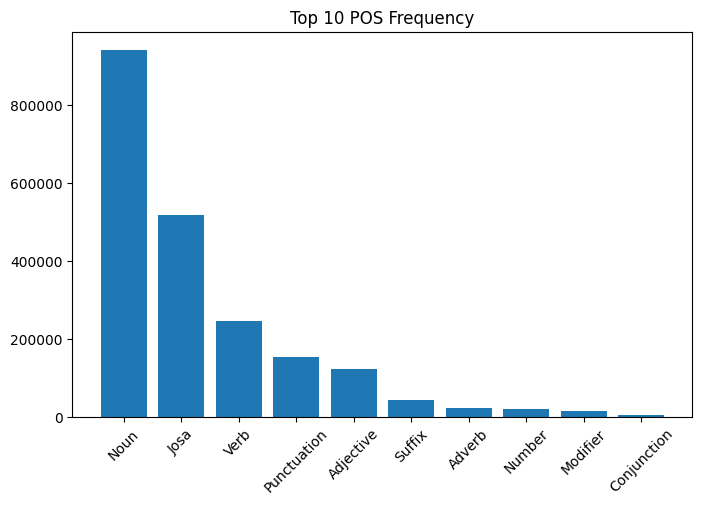

In [27]:
import matplotlib.pyplot as plt

top_pos = overall_pos_df.head(10)

plt.figure(figsize=(8, 5))
plt.bar(top_pos["pos"], top_pos["count"])
plt.xticks(rotation=45)
plt.title("Top 10 POS Frequency")
plt.show()

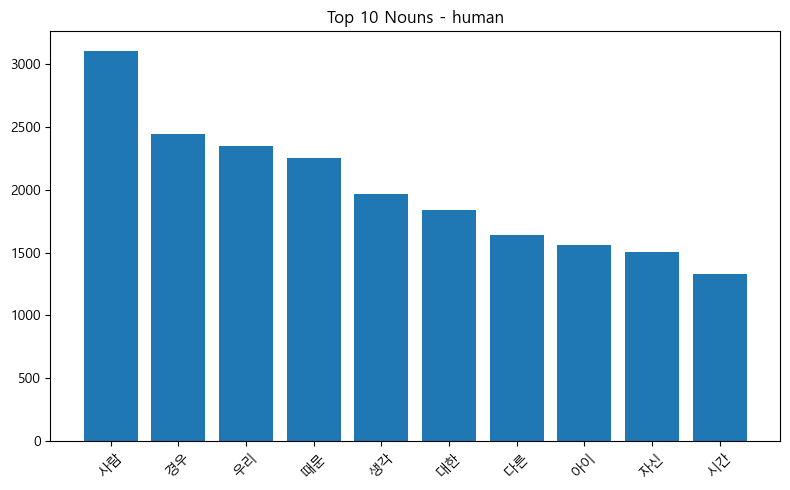

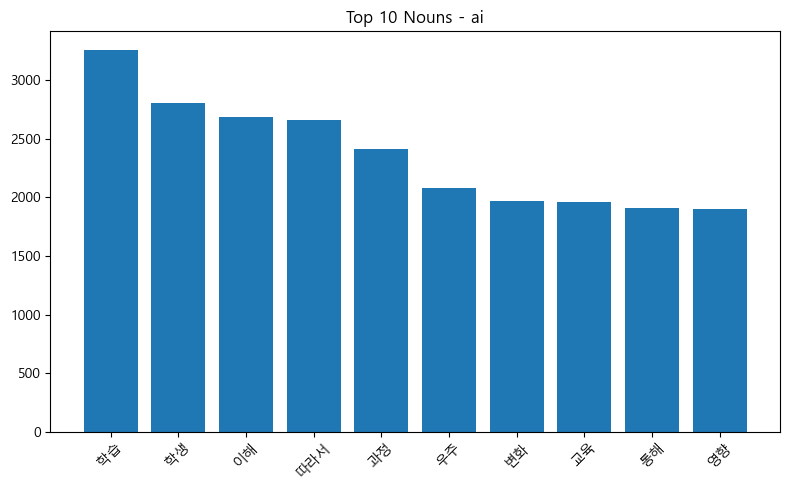

In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (Windows)
mpl.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
mpl.rcParams["axes.unicode_minus"] = False

for source in ["human", "ai"]:
    temp = noun_freq_by_source[noun_freq_by_source["source"] == source].head(10)

    plt.figure(figsize=(8, 5))
    plt.bar(temp["noun"], temp["count"])
    plt.xticks(rotation=45)
    plt.title(f"Top 10 Nouns - {source}")
    plt.tight_layout()
    plt.show()

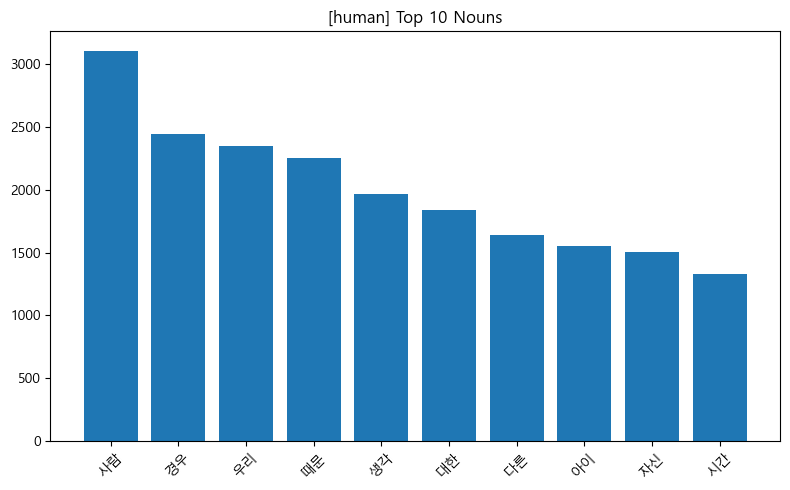

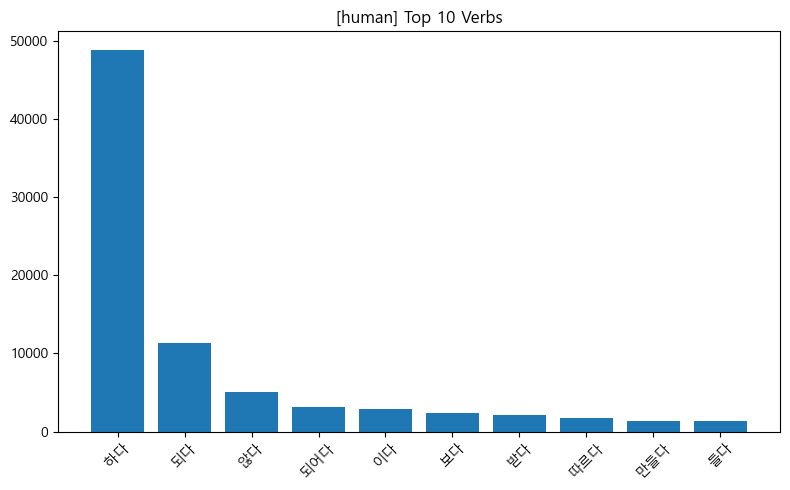

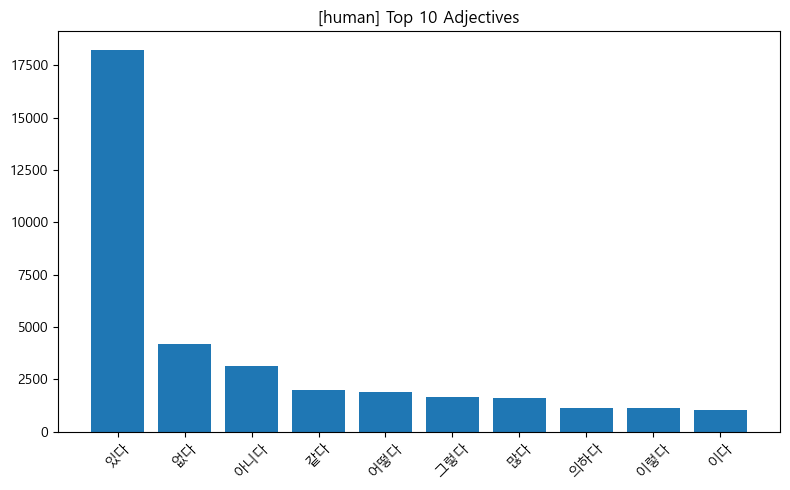

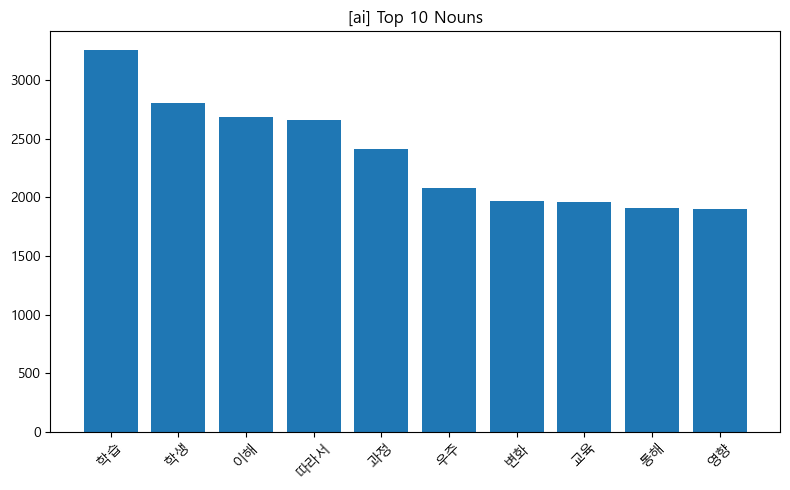

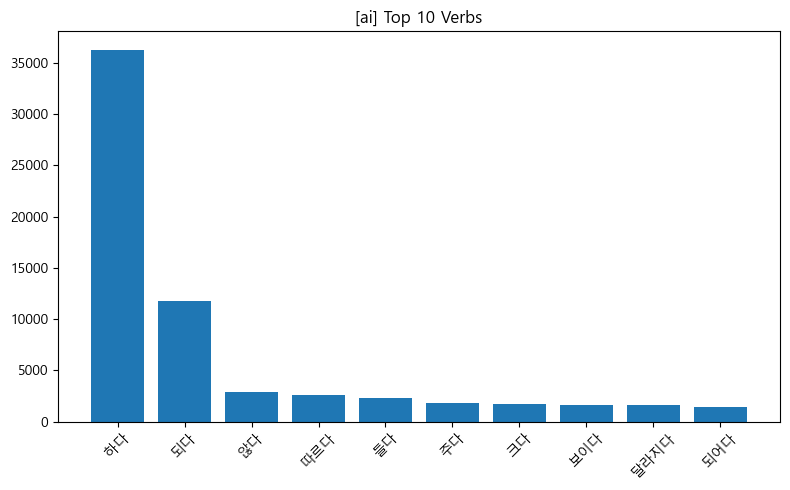

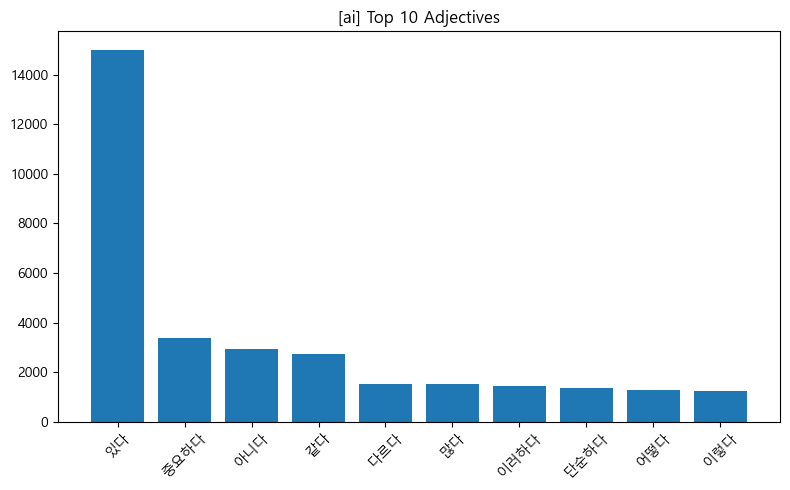

In [42]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

def plot_top_words(counter, title, top_n=10):
    top_items = counter.most_common(top_n)
    
    words = [w for w, c in top_items]
    counts = [c for w, c in top_items]
    
    plt.figure(figsize=(8, 5))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()

from collections import Counter

def get_pos_word_counter(pos_series, target_tag, min_len=2):
    counter = Counter()
    
    for pos_list in pos_series:
        for word, tag in pos_list:
            if tag == target_tag and len(word) >= min_len:
                counter[word] += 1
                
    return counter

    
for source in ["human", "ai"]:
    subset = data[data["source"] == source]
    
    # 품사별 Counter 생성
    noun_counter = get_pos_word_counter(subset["pos_result"], "Noun")
    verb_counter = get_pos_word_counter(subset["pos_result"], "Verb")
    adj_counter  = get_pos_word_counter(subset["pos_result"], "Adjective")
    
    # 시각화
    plot_top_words(noun_counter, f"[{source}] Top 10 Nouns")
    plot_top_words(verb_counter, f"[{source}] Top 10 Verbs")
    plot_top_words(adj_counter,  f"[{source}] Top 10 Adjectives")

---

# 02. 문장 임베딩 구성

### 1) 문장 임베딩 생성

In [33]:
import os
import numpy as np
from tqdm.auto import tqdm

texts = data["clean_text"].tolist()
batch_size = 5000
save_dir = "../data/results/embeddings/chunks"
os.makedirs(save_dir, exist_ok=True)

all_paths = []

for start in tqdm(range(0, len(texts), batch_size)):
    end = min(start + batch_size, len(texts))
    batch_texts = texts[start:end]
    
    batch_emb = model.encode(
        batch_texts,
        batch_size=64,
        show_progress_bar=False,
        convert_to_numpy=True
    )
    
    save_path = os.path.join(save_dir, f"emb_{start}_{end}.npy")
    np.save(save_path, batch_emb)
    all_paths.append(save_path)

print("저장 완료:", len(all_paths))

100%|█████████████████████████████████████████████████████████████████████████████████| 20/20 [49:58<00:00, 149.91s/it]

저장 완료: 20


In [34]:
import glob

def get_start_idx(path):
    filename = os.path.basename(path)          # emb_0_5000.npy
    start_idx = int(filename.split("_")[1])    # 0
    return start_idx

chunk_files = glob.glob("../data/results/embeddings/chunks/*.npy")
chunk_files = sorted(chunk_files, key=get_start_idx)

emb_list = [np.load(f) for f in chunk_files]
embeddings = np.vstack(emb_list)

os.makedirs("../data/results/embeddings", exist_ok=True)
np.save("../data/results/embeddings/sentence_embeddings.npy", embeddings)

metadata = data[["text", "clean_text", "source", "topic_code", "topic_name", "word_count", "length_bin"]].copy()
metadata.to_csv("../data/results/embeddings/embedding_metadata.csv", index=False, encoding="utf-8-sig")

embeddings = np.load("../data/results/embeddings/sentence_embeddings.npy")
metadata = pd.read_csv("../data/results/embeddings/embedding_metadata.csv")

print("embeddings shape:", embeddings.shape)
print("metadata shape:", metadata.shape)

assert len(embeddings) == len(metadata), "임베딩 개수와 metadata 행 개수가 다릅니다."

embeddings shape: (100000, 384)
metadata shape: (100000, 7)


### 2) 임베딩 기반 비교

2-1) source별 평균 벡터

In [35]:
human_emb = embeddings[data["source"] == "human"]
ai_emb = embeddings[data["source"] == "ai"]

human_mean = human_emb.mean(axis=0)
ai_mean = ai_emb.mean(axis=0)

print(human_mean.shape, ai_mean.shape)

(384,) (384,)


2-2) 코사인 유사도

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity([human_mean], [ai_mean])[0][0]
print("Human-AI 평균 벡터 코사인 유사도:", sim)

Human-AI 평균 벡터 코사인 유사도: 0.75288177


2-3) 차원 축소 후 시각화

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12380\2768775303.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = data.groupby("source", group_keys=False).apply(lambda x: x.sample(2000, random_state=42)).reset_index(drop=True)
C:\Users\sunabc1023\AppData\Local\anaconda3\envs\tda\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


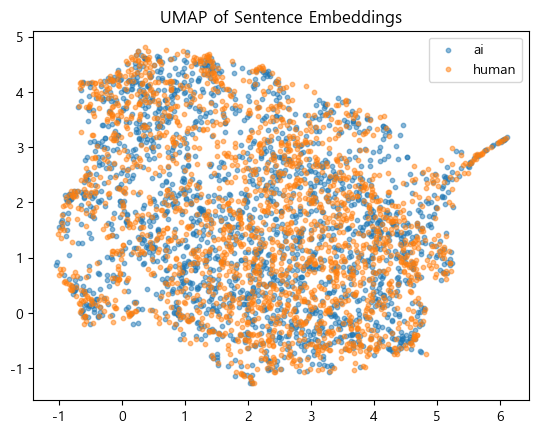

In [38]:
import umap
import matplotlib.pyplot as plt

sample_df = data.groupby("source", group_keys=False).apply(lambda x: x.sample(2000, random_state=42)).reset_index(drop=True)
sample_idx = sample_df.index.tolist()

sample_emb = embeddings[sample_idx]

reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(sample_emb)

plot_df = sample_df.copy()
plot_df["x"] = emb_2d[:, 0]
plot_df["y"] = emb_2d[:, 1]

for source in plot_df["source"].unique():
    temp = plot_df[plot_df["source"] == source]
    plt.scatter(temp["x"], temp["y"], label=source, alpha=0.5, s=10)

plt.legend()
plt.title("UMAP of Sentence Embeddings")
plt.show()

---

# 03. 단어 임베딩

In [38]:
from collections import Counter
import pandas as pd

TOPIC_COL = "topic_name"

def show_topic_top_words(data, topic, topn=30):
    topic_df = data[data[TOPIC_COL] == topic].copy()
    
    human_df = topic_df[topic_df["source"] == "human"]
    ai_df = topic_df[topic_df["source"] == "ai"]
    
    human_counter = Counter([t for s in human_df["tokens_ft"] for t in s])
    ai_counter = Counter([t for s in ai_df["tokens_ft"] for t in s])
    
    human_top = pd.DataFrame(human_counter.most_common(topn), columns=["word", "human_count"])
    ai_top = pd.DataFrame(ai_counter.most_common(topn), columns=["word", "ai_count"])
    
    merged = pd.merge(human_top, ai_top, on="word", how="outer").fillna(0)
    merged["human_count"] = merged["human_count"].astype(int)
    merged["ai_count"] = merged["ai_count"].astype(int)
    merged["total_count"] = merged["human_count"] + merged["ai_count"]
    merged = merged.sort_values("total_count", ascending=False).reset_index(drop=True)
    
    print(f"\n[{topic}] 상위 단어")
    display(merged.head(topn))


# show_topic_top_words(data, "경제학", topn=30)
# show_topic_top_words(data, "법률·법학", topn=30)
# show_topic_top_words(data, "교육학", topn=30)
# show_topic_top_words(data, "자연과학", topn=30)
show_topic_top_words(data, "천문학", topn=30)


[천문학] 상위 단어


,word,human_count,ai_count,total_count
0,으로,1896,1909,3805
1,에서,1812,1171,2983
2,우주,963,1999,2962
3,은하,373,1592,1965
4,행성,423,1502,1925
5,관측,303,1546,1849
6,천체,0,1759,1759
7,지구,729,822,1551
8,않다,870,554,1424
9,중력,0,1226,1226


In [39]:
TARGET_WORDS_BY_TOPIC = {
    "경제학": ["기업", "투자"],
    "법률·법학": ["행위", "절차"],
    "교육학": ["학습", "학생"],
    "자연과학": ["에너지", "지구"],
    "천문학": ["우주", "행성"]
}

데이터 크기: (100000, 10)
컬럼 목록: ['text', 'word_count', 'length_bin', 'topic_code', 'topic_name', 'source', 'clean_text', 'pos_result', 'tokens', 'nouns']


,text,word_count,length_bin,topic_code,topic_name,source,clean_text,pos_result,tokens,nouns
0,그러면서 기술과 자본이 어우러져 만들어내는 생산력이 19세기 패권 경쟁에서 가장 중...,13,10-14,320,경제학,human,그러면서 기술과 자본이 어우러져 만들어내는 생산력이 19세기 패권 경쟁에서 가장 중...,"[(그렇다, Adjective), (기술, Noun), (과, Josa), (자본,...","[그렇다, 기술, 과, 자본, 이, 어우러지다, 만들다, 생산력, 이, 19, 세기...","[기술, 자본, 생산력, 세기, 패권, 경쟁, 가장, 요소]"
1,그렇다면 차를 살 때도 약간의 수고를 감수하고 바지런을 떠는 게 더 좋지 않을까.,13,10-14,320,경제학,human,그렇다면 차를 살 때도 약간의 수고를 감수하고 바지런을 떠는 게 더 좋지 않을까.,"[(그렇다, Adjective), (차, Noun), (를, Josa), (살, N...","[그렇다, 차, 를, 살, 때, 도, 약간, 의, 수고, 를, 감수, 하고, 바지런...","[차, 살, 때, 약간, 수고, 감수, 바지런, 게, 더]"
2,그 마음으로 여러분만의 '사이드 프로젝트'를 시작하세요.,6,5-9,320,경제학,human,그 마음으로 여러분만의 '사이드 프로젝트'를 시작하세요.,"[(그, Noun), (마음, Noun), (으로, Josa), (여러분, Noun...","[그, 마음, 으로, 여러분, 만의, ', 사이드, 프로젝트, ', 를, 시작, 하...","[그, 마음, 여러분, 사이드, 프로젝트, 를, 시작]"
3,그러나 나는 입사해서 지금까지 매일 받는 봉사료를 모아서 생활비로 쓰고 있다.,11,10-14,320,경제학,human,그러나 나는 입사해서 지금까지 매일 받는 봉사료를 모아서 생활비로 쓰고 있다.,"[(그러나, Conjunction), (나, Noun), (는, Josa), (입사...","[그러나, 나, 는, 입사, 하다, 지금, 까지, 매일, 받다, 봉사, 료, 를, ...","[나, 입사, 지금, 매일, 봉사, 료, 생활비]"
4,"'사회운동노조주의'는 노조 스스로 정치적으로 강화돼야 한다고 하지만, 그것이 어떤 ...",11,10-14,320,경제학,human,"'사회운동노조주의'는 노조 스스로 정치적으로 강화돼야 한다고 하지만, 그것이 어떤 ...","[(', Punctuation), (사회, Noun), (운동, Noun), (노조...","[', 사회, 운동, 노조, 주의, ', 늘다, 노조, 스스로, 정치, 적, 으로,...","[사회, 운동, 노조, 주의, 노조, 스스로, 정치, 강화, 그것, 정치인, 불분명]"



[tokens_ft 예시]


,topic_name,source,tokens_ft
0,경제학,human,"[그렇다, 기술, 자본, 어우러지다, 만들다, 생산력, 세기, 패권, 경쟁, 가장,..."
1,경제학,human,"[그렇다, 약간, 수고, 감수, 바지런, 뜨다, 좋다]"
2,경제학,human,"[마음, 여러분, 사이드, 프로젝트, 시작]"
3,경제학,human,"[입사, 지금, 매일, 받다, 봉사, 모으다, 생활비, 쓰다]"
4,경제학,human,"[사회, 운동, 노조, 주의, 늘다, 노조, 스스로, 정치, 강화, 돼다, 그것, ..."



주제 목록: ['경제학' '법률·법학' '교육학' '자연과학' '천문학']

Human 문장 수: 49990
AI 문장 수: 50000

Human vocab size: 10833
AI vocab size: 3542

FastText 모델 저장 완료

[주제] 경제학

[단어 존재 여부]


,word,in_human_vocab,in_ai_vocab,topic
0,기업,True,True,경제학
1,투자,True,True,경제학



[주제별 단어 빈도표]


,topic,word,human_count,ai_count,total_count
0,경제학,기업,444,1328,1772
1,경제학,투자,309,546,855


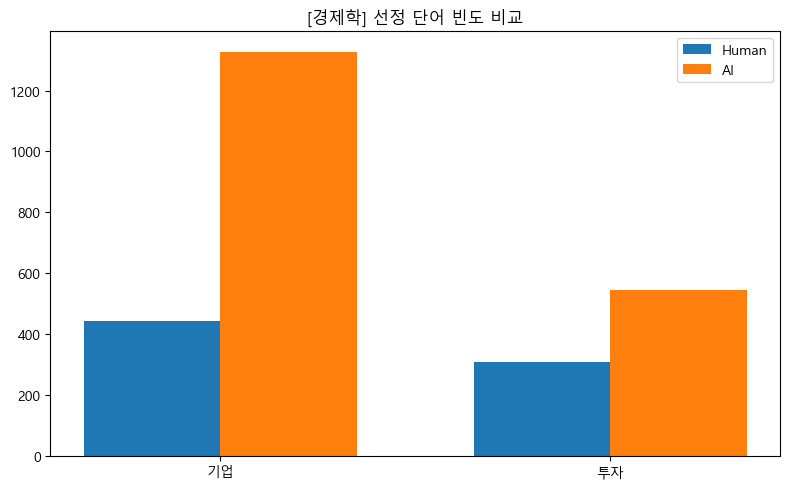


--- [경제학] '기업' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,경제학,기업,1,대기업,0.733056,실적,0.611921
1,경제학,기업,2,기업인,0.696101,해외여행,0.605406
2,경제학,기업,3,기업가,0.694234,투자,0.578486
3,경제학,기업,4,기업체,0.684123,판매,0.570095
4,경제학,기업,5,공기업,0.678861,상품,0.568507
5,경제학,기업,6,중소기업,0.652299,수익,0.567299
6,경제학,기업,7,재무,0.638010,대기업,0.565191
7,경제학,기업,8,경영,0.637554,경쟁자,0.563950
8,경제학,기업,9,경쟁자,0.613733,시장,0.556331
9,경제학,기업,10,투자자,0.610374,신규,0.552766


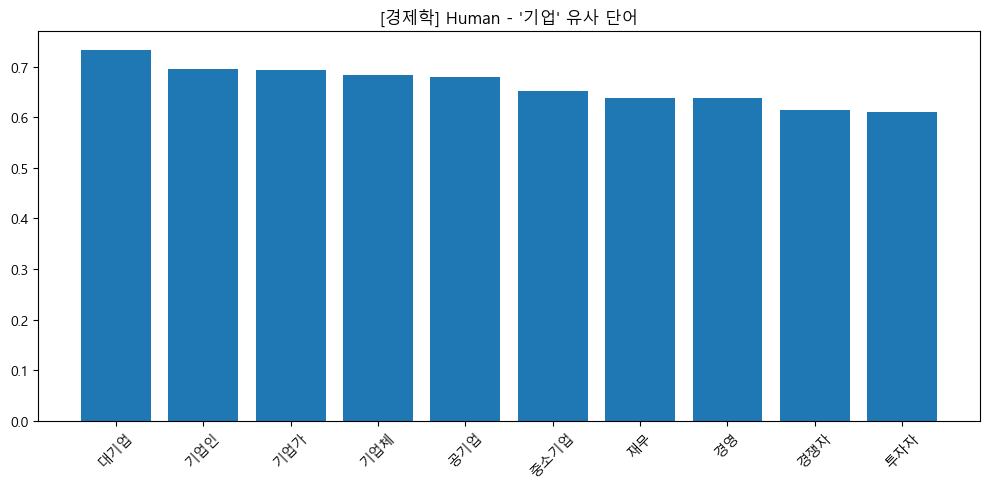

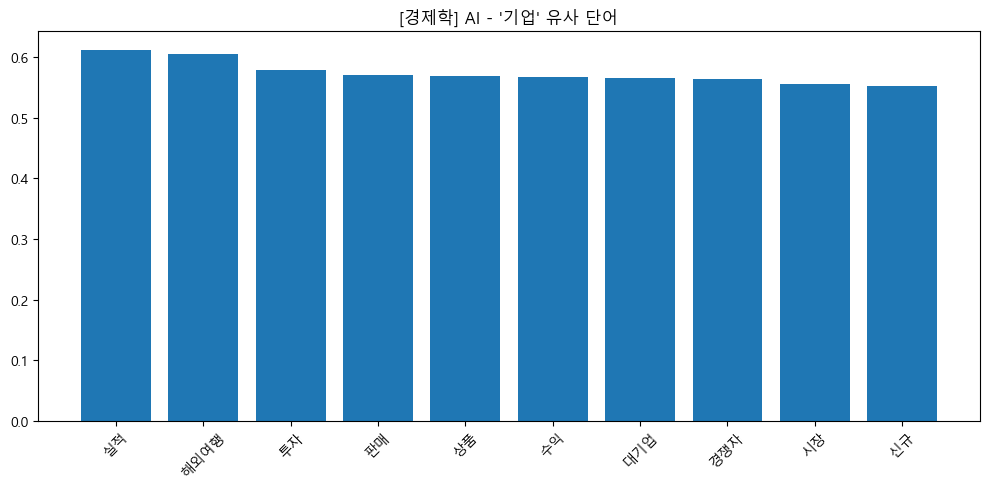

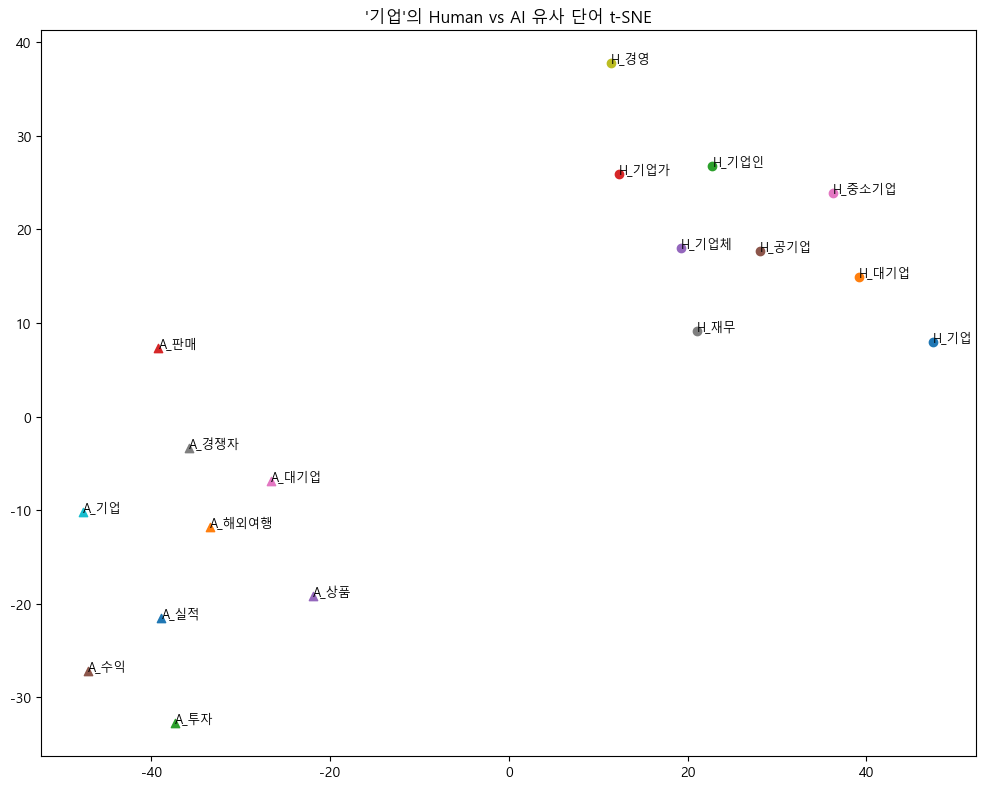


--- [경제학] '투자' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,경제학,투자,1,투자가,0.806202,투자가,0.743185
1,경제학,투자,2,투자자,0.777162,조달,0.657408
2,경제학,투자,3,주식,0.739355,가계도,0.652162
3,경제학,투자,4,투자신탁,0.713156,가계부채,0.651709
4,경제학,투자,5,펀드,0.712601,자본시장,0.651024
5,경제학,투자,6,회사채,0.695199,차입,0.645586
6,경제학,투자,7,수익,0.688638,실적,0.645033
7,경제학,투자,8,수익금,0.687142,수익,0.638991
8,경제학,투자,9,자본금,0.683181,불황,0.624366
9,경제학,투자,10,주식시장,0.681929,주식시장,0.619611


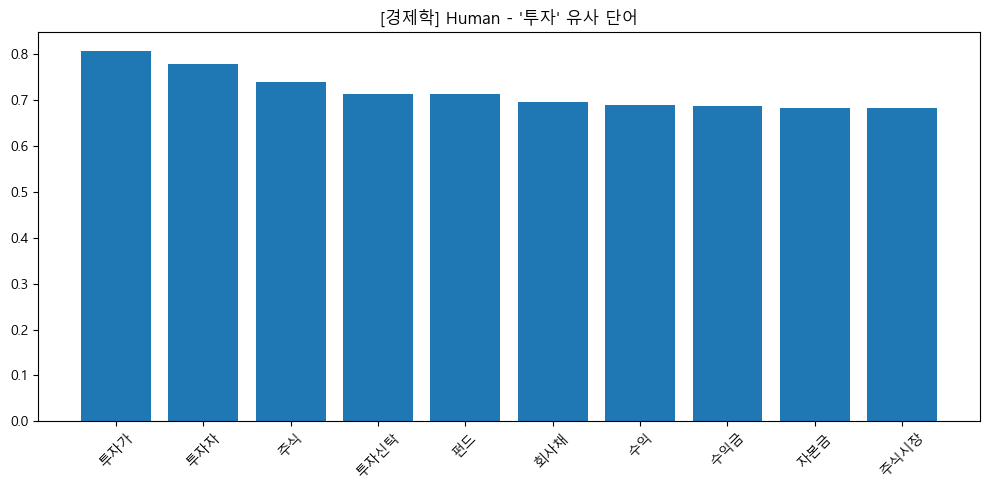

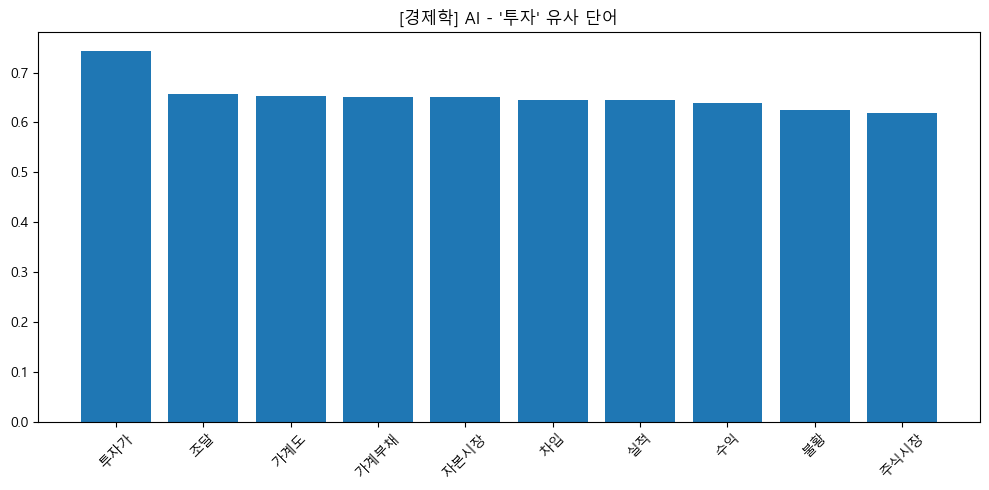

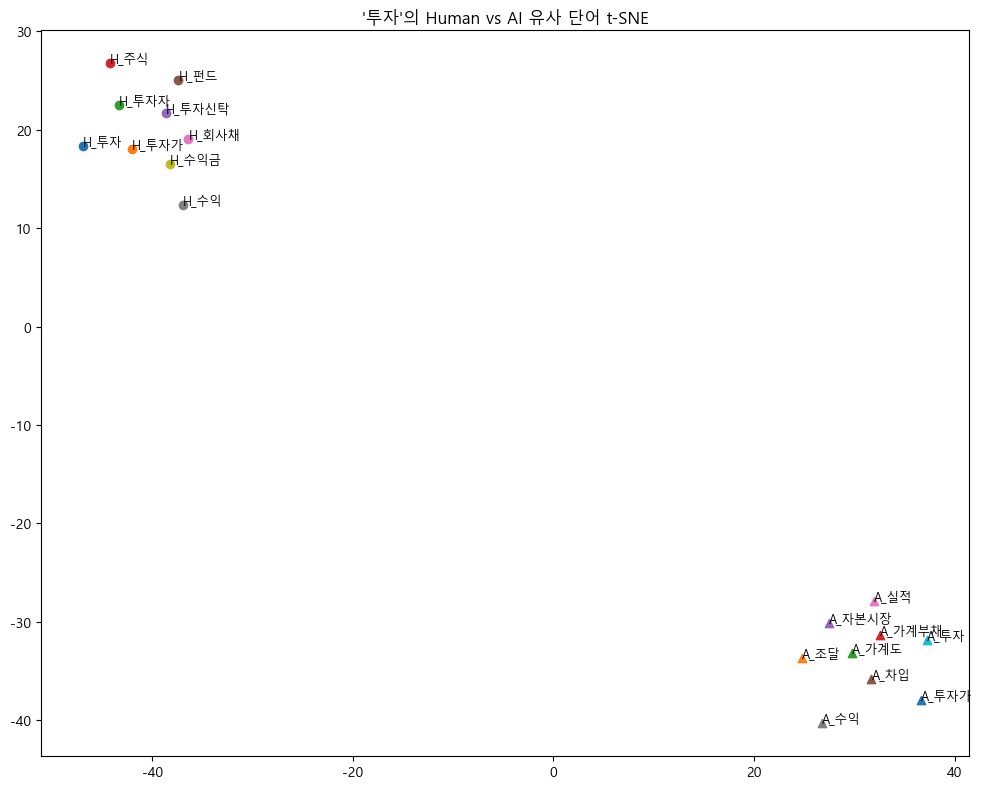


[주제] 법률·법학

[단어 존재 여부]


,word,in_human_vocab,in_ai_vocab,topic
0,행위,True,True,법률·법학
1,절차,True,True,법률·법학



[주제별 단어 빈도표]


,topic,word,human_count,ai_count,total_count
0,법률·법학,행위,575,637,1212
1,법률·법학,절차,297,898,1195


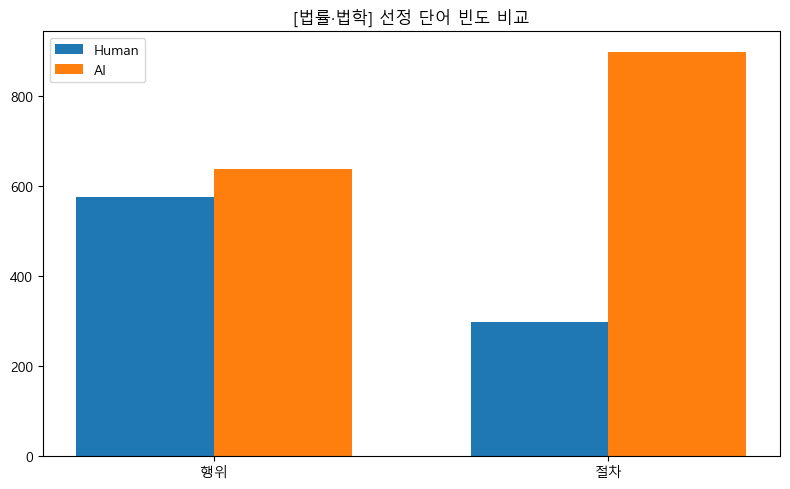


--- [법률·법학] '행위' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,법률·법학,행위,1,위법행위,0.768616,위법행위,0.652334
1,법률·법학,행위,2,기망행위,0.746804,불법행위,0.643797
2,법률·법학,행위,3,공법행위,0.739488,행위자,0.595203
3,법률·법학,행위,4,불법행위,0.699657,불법행위법,0.571670
4,법률·법학,행위,5,기속행위,0.686642,법률상,0.570085
5,법률·법학,행위,6,알선,0.685633,책임능력,0.564306
6,법률·법학,행위,7,행위자,0.674942,법률행위,0.558676
7,법률·법학,행위,8,과실,0.672390,불이익,0.551026
8,법률·법학,행위,9,주거침입,0.671739,손해배상,0.549545
9,법률·법학,행위,10,부수,0.671333,잘못,0.547339


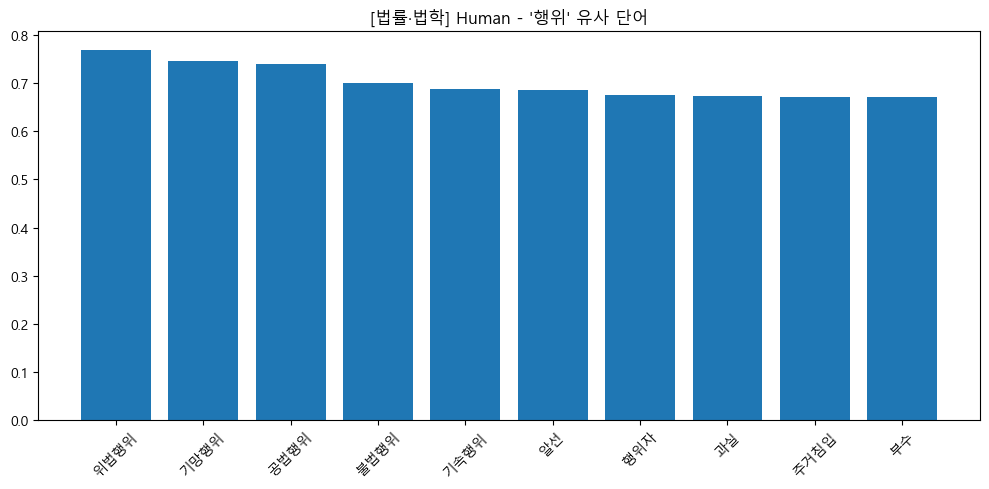

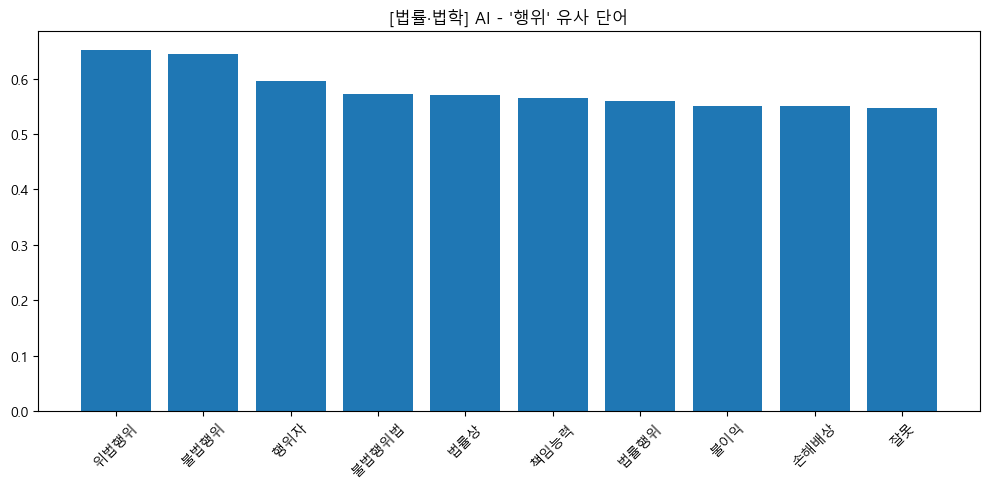

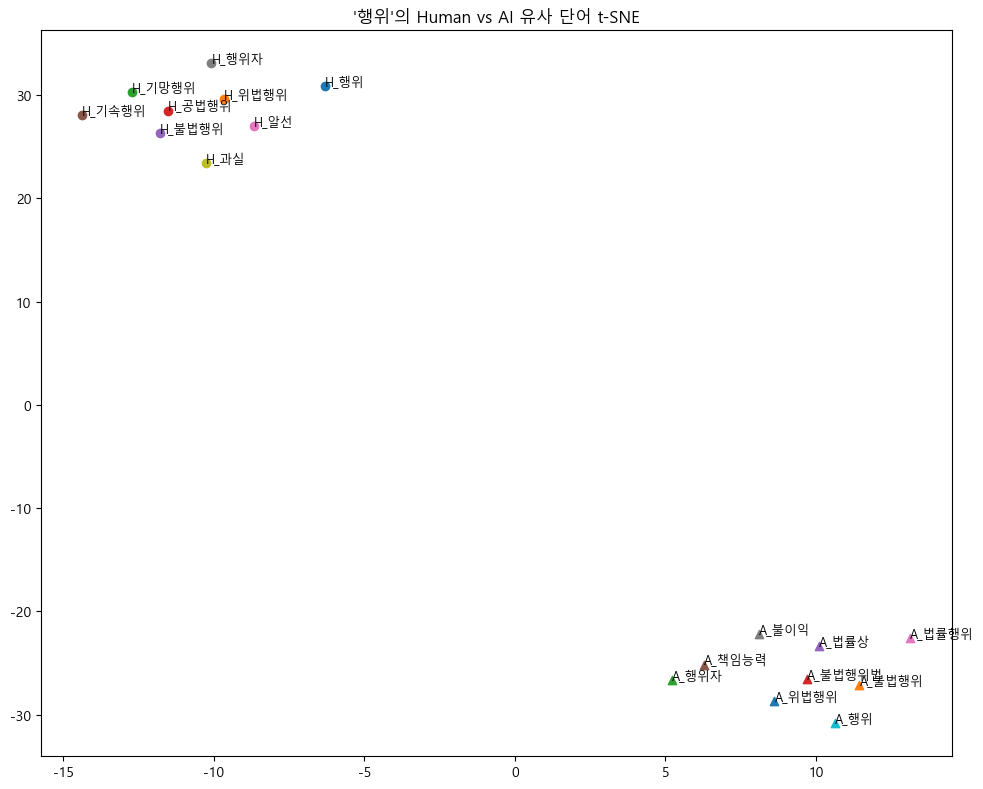


--- [법률·법학] '절차' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,법률·법학,절차,1,파산법,0.744686,실체,0.708791
1,법률·법학,절차,2,회생,0.735316,재판,0.707305
2,법률·법학,절차,3,도산,0.728855,행정절차,0.673234
3,법률·법학,절차,4,구술,0.726811,소송,0.662086
4,법률·법학,절차,5,의견청취,0.719869,정당성,0.660038
5,법률·법학,절차,6,계고처분,0.719801,적법절차,0.636301
6,법률·법학,절차,7,소송요건,0.715312,행정소송,0.636228
7,법률·법학,절차,8,본안,0.708441,수사,0.614126
8,법률·법학,절차,9,각하,0.703875,형사재판,0.607883
9,법률·법학,절차,10,현행법,0.703519,구제,0.595395


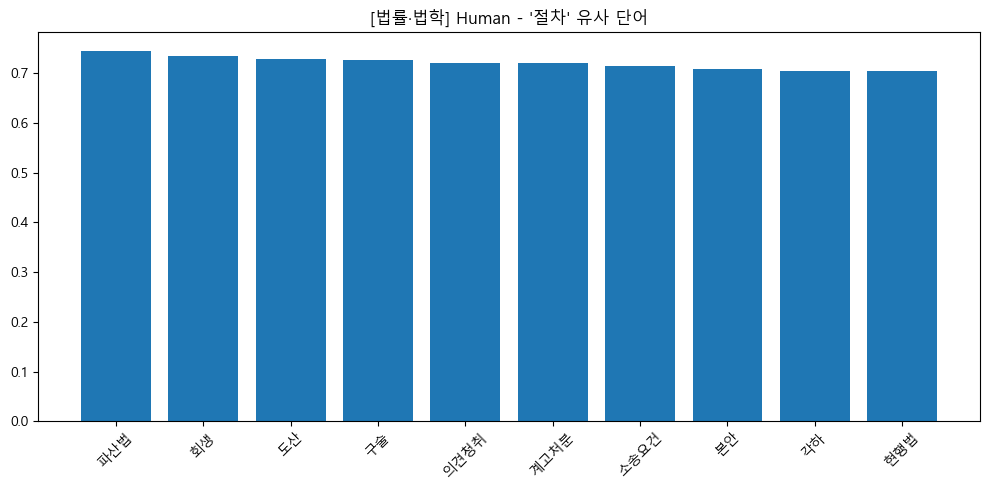

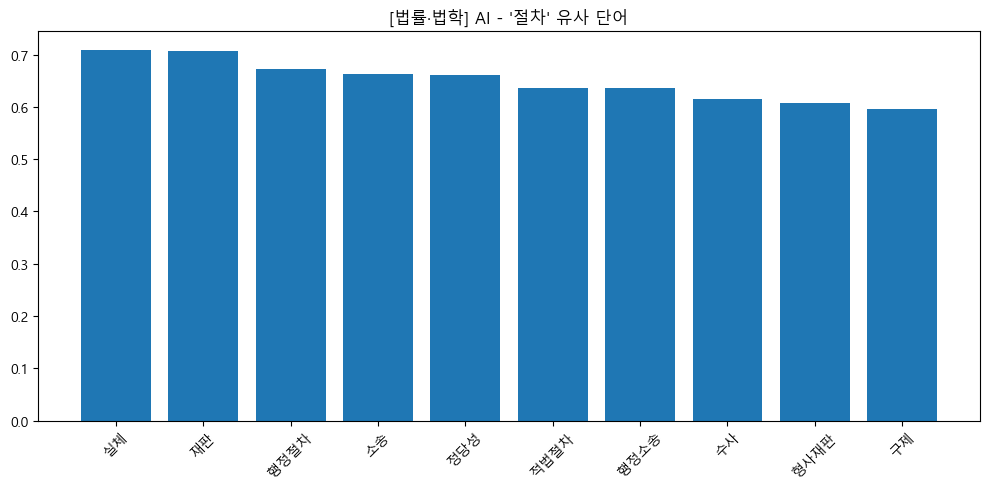

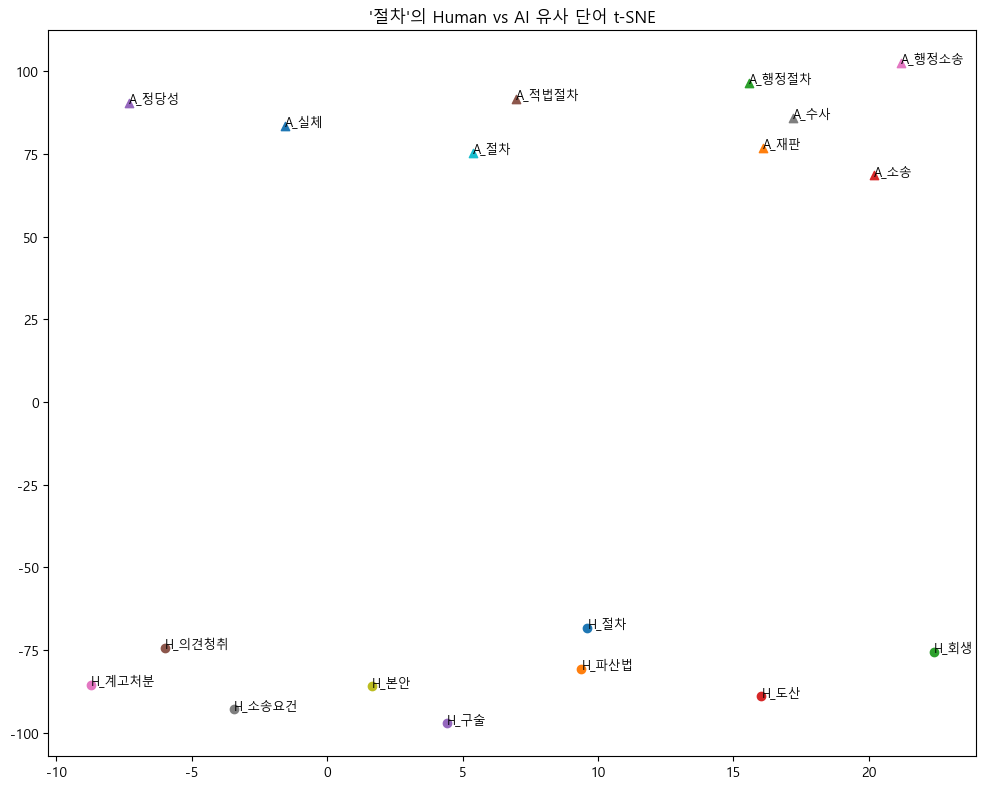


[주제] 교육학

[단어 존재 여부]


,word,in_human_vocab,in_ai_vocab,topic
0,학습,True,True,교육학
1,학생,True,True,교육학



[주제별 단어 빈도표]


,topic,word,human_count,ai_count,total_count
0,교육학,학습,351,3251,3602
1,교육학,학생,751,2792,3543


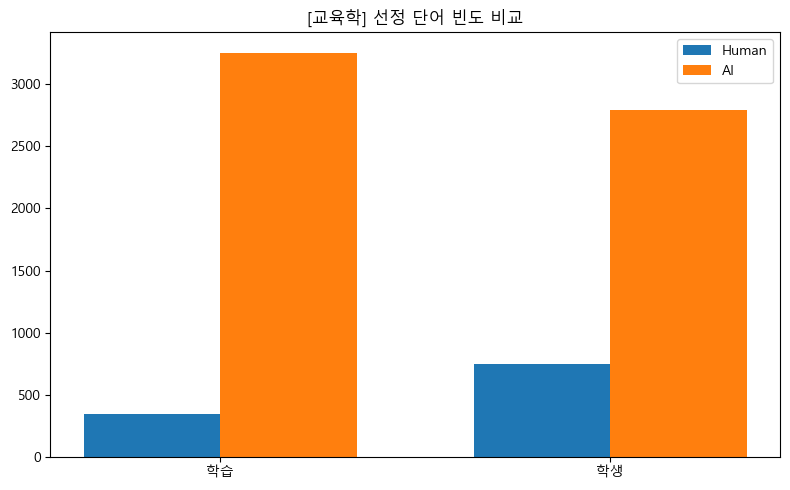


--- [교육학] '학습' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,교육학,학습,1,학습자,0.771059,수업,0.737383
1,교육학,학습,2,체험학습,0.703431,학습자,0.710070
2,교육학,학습,3,주도,0.657705,학생,0.706661
3,교육학,학습,4,글쓰기,0.653327,교육,0.671952
4,교육학,학습,5,수업,0.649887,배움,0.655322
5,교육학,학습,6,동기부여,0.647047,피드백,0.646793
6,교육학,학습,7,협동,0.645514,성취도,0.643002
7,교육학,학습,8,수행평가,0.640315,성취,0.625798
8,교육학,학습,9,교육활동,0.635237,교육활동,0.618193
9,교육학,학습,10,진로,0.632557,교사,0.616937


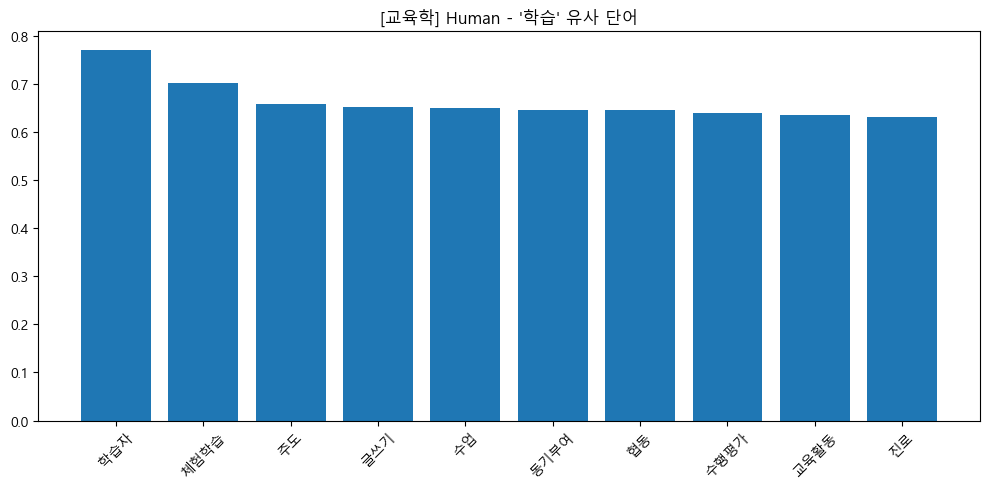

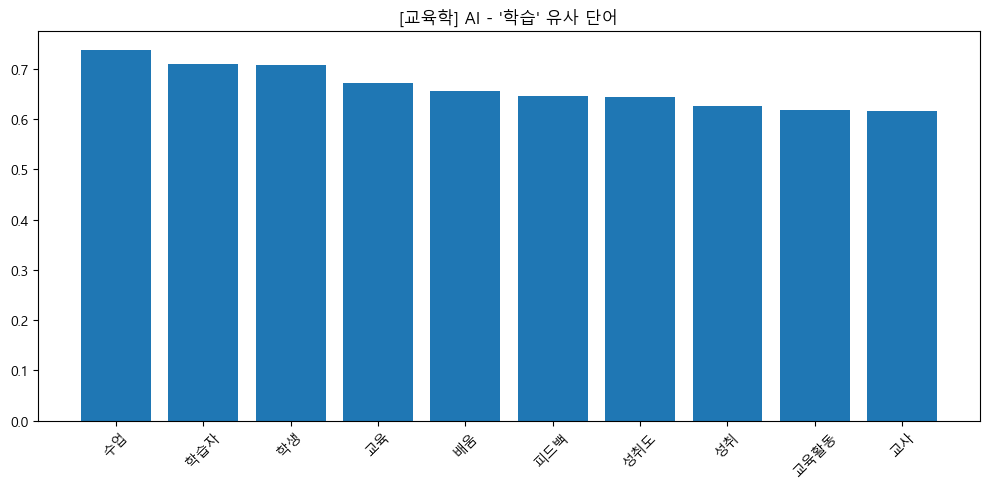

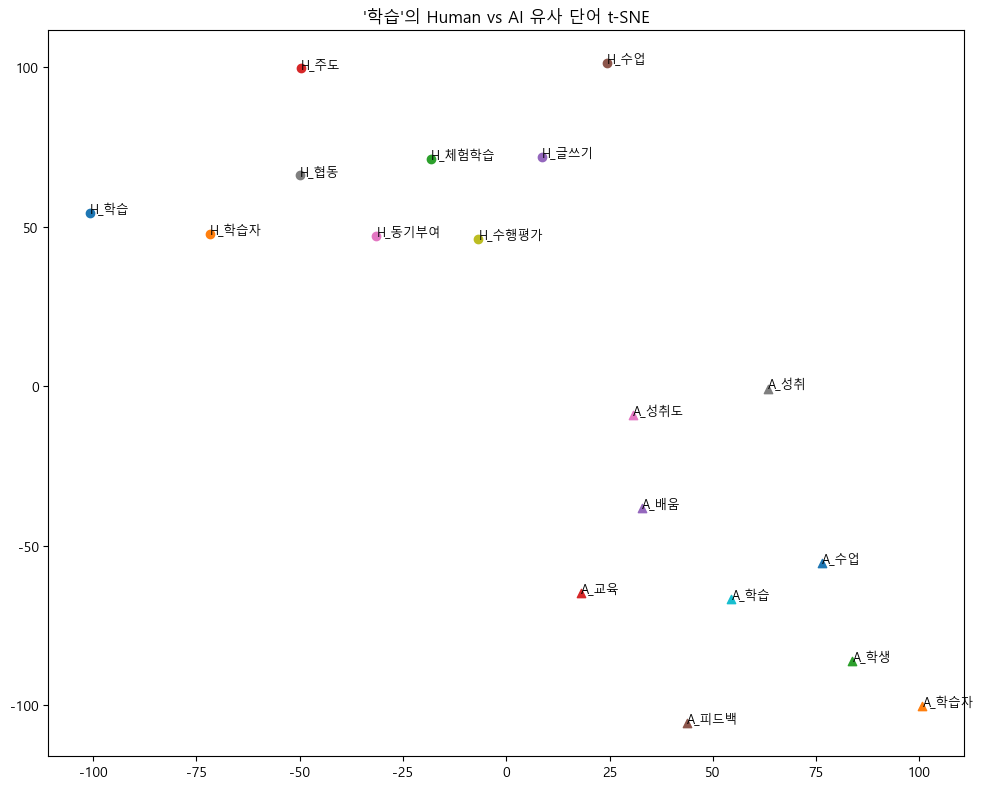


--- [교육학] '학생' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,교육학,학생,1,중학생,0.718018,학습자,0.819871
1,교육학,학생,2,학급,0.704774,학습,0.706661
2,교육학,학생,3,남학생,0.695827,수업,0.678774
3,교육학,학생,4,대학생,0.693024,교사,0.665640
4,교육학,학생,5,초등학생,0.673925,안내,0.637965
5,교육학,학생,6,학생회,0.670155,정기,0.627104
6,교육학,학생,7,여학생,0.649728,적성,0.619427
7,교육학,학생,8,고등학생,0.641182,격려,0.613630
8,교육학,학생,9,유학생,0.631975,과목,0.612816
9,교육학,학생,10,교사,0.629285,친구,0.612447


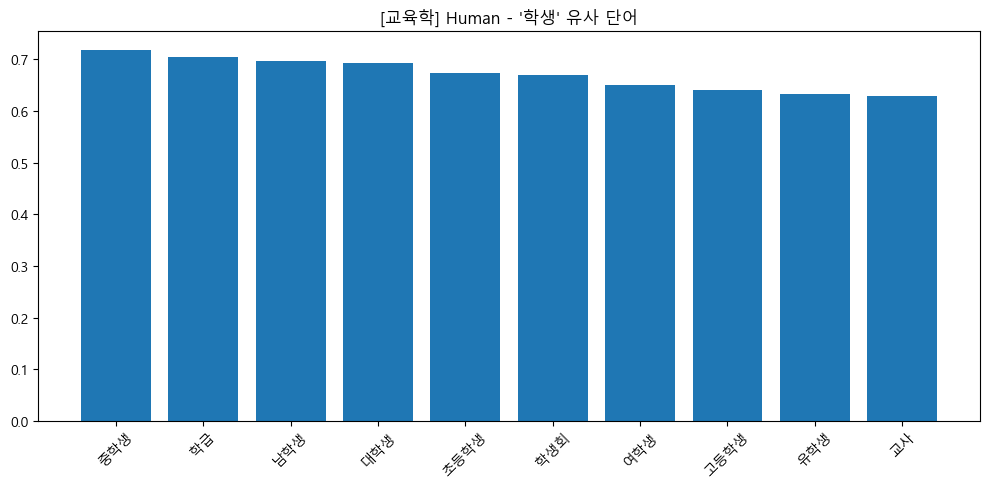

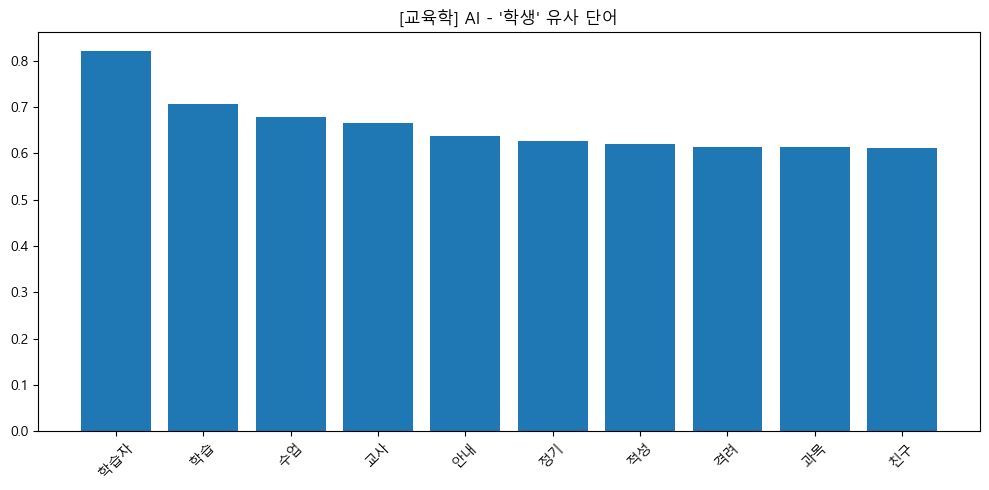

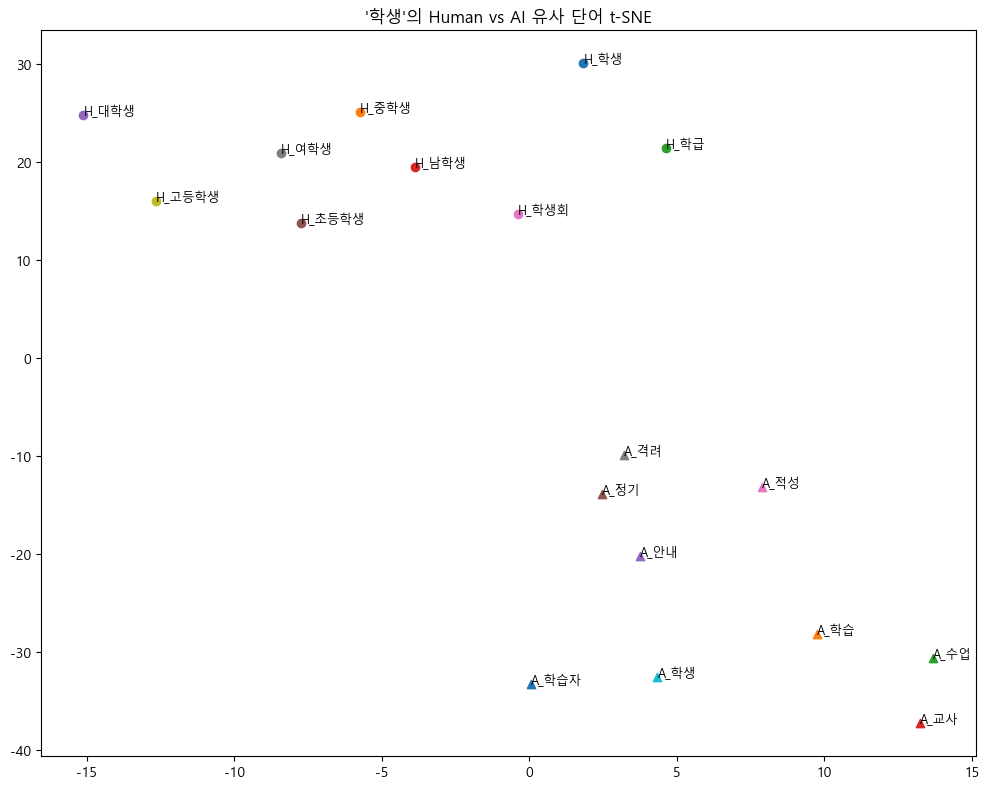


[주제] 자연과학

[단어 존재 여부]


,word,in_human_vocab,in_ai_vocab,topic
0,에너지,True,True,자연과학
1,지구,True,True,자연과학



[주제별 단어 빈도표]


,topic,word,human_count,ai_count,total_count
0,자연과학,에너지,221,1024,1245
1,자연과학,지구,360,521,881


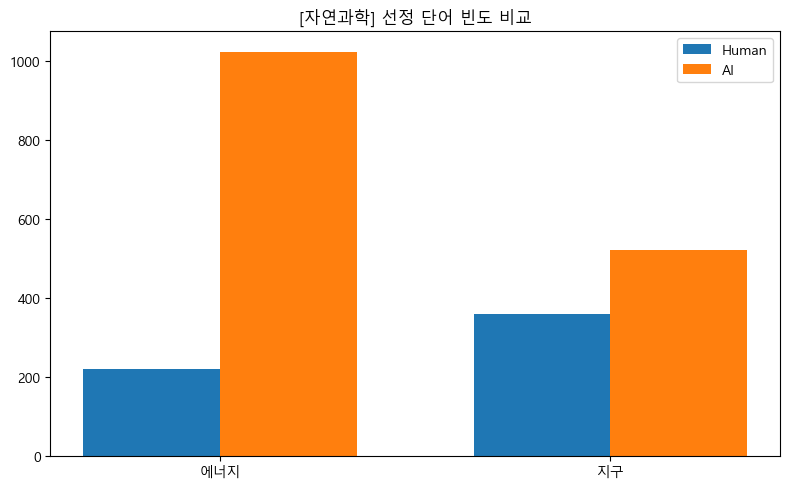


--- [자연과학] '에너지' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,자연과학,에너지,1,위치에너지,0.863106,운동에너지,0.781363
1,자연과학,에너지,2,운동에너지,0.809716,방출,0.649333
2,자연과학,에너지,3,암흑에너지,0.790966,빛과,0.615543
3,자연과학,에너지,4,방출,0.701039,변환,0.571427
4,자연과학,에너지,5,뉴트리노,0.695888,일어나며,0.570543
5,자연과학,에너지,6,핵분열,0.695837,호흡,0.570166
6,자연과학,에너지,7,흡수,0.695054,일어난다,0.558977
7,자연과학,에너지,8,소모,0.693928,태양도,0.555807
8,자연과학,에너지,9,핵반응,0.690292,태양광,0.545975
9,자연과학,에너지,10,광자,0.687359,내미다,0.541611


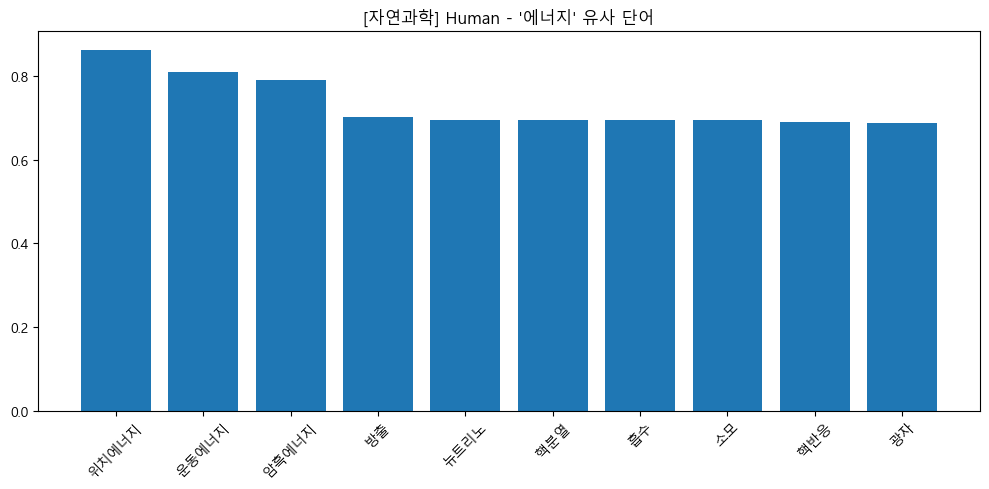

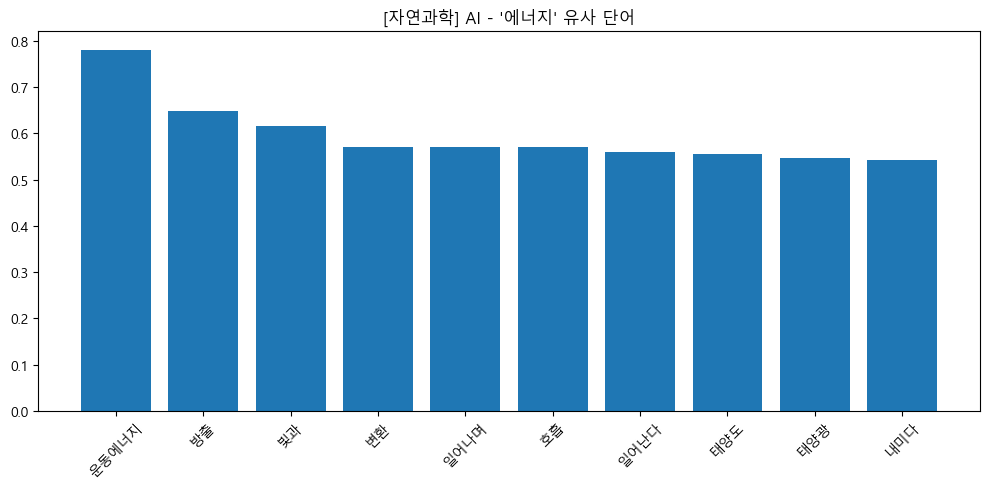

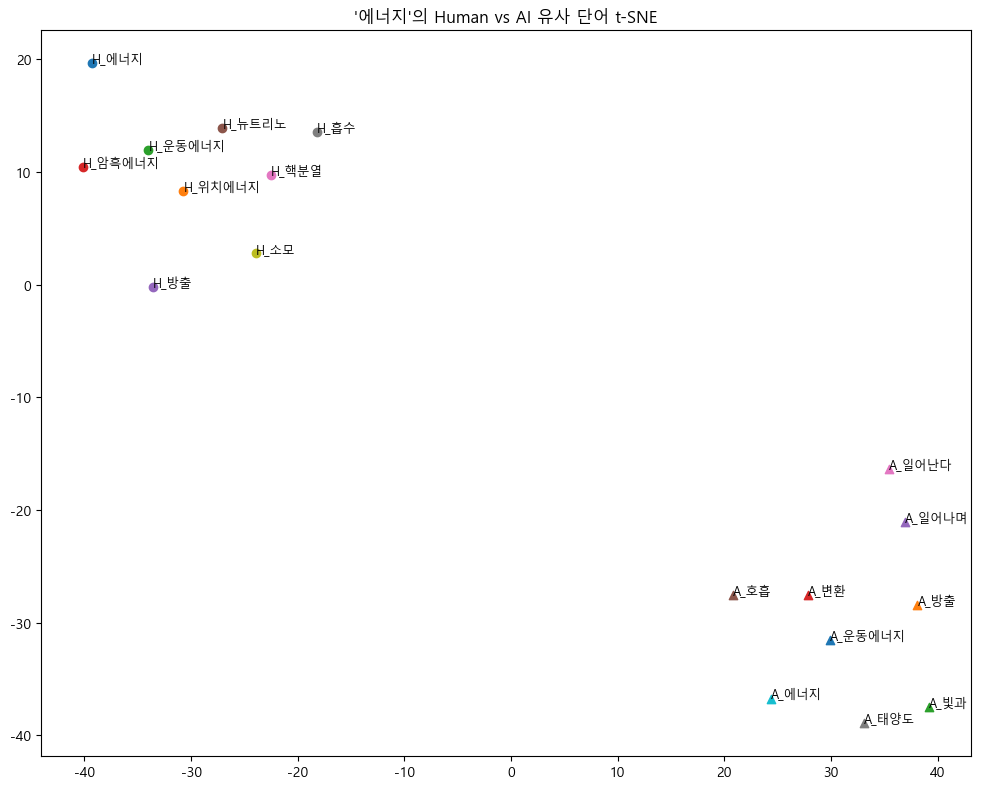


--- [자연과학] '지구' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,자연과학,지구,1,지구인,0.757279,달이,0.627988
1,자연과학,지구,2,지구촌,0.747862,태양,0.611684
2,자연과학,지구,3,화성,0.663194,자연위성,0.593843
3,자연과학,지구,4,태양일,0.659496,태양빛,0.586073
4,자연과학,지구,5,공전,0.655230,일식,0.566203
5,자연과학,지구,6,자전,0.648004,개기월식,0.561430
6,자연과학,지구,7,태양열,0.644797,월식,0.559941
7,자연과학,지구,8,태양빛,0.638478,주위,0.557395
8,자연과학,지구,9,태양계,0.635058,공전,0.556505
9,자연과학,지구,10,태양광,0.628152,태양도,0.551370


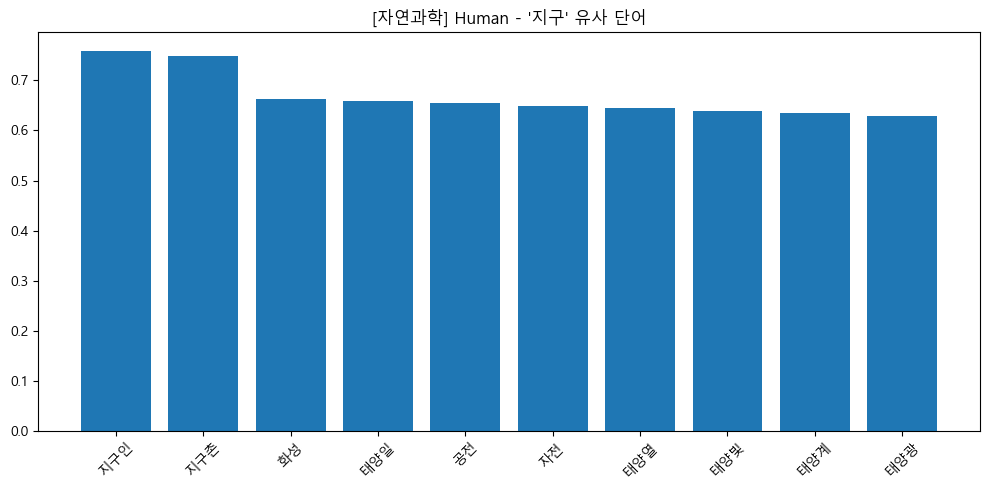

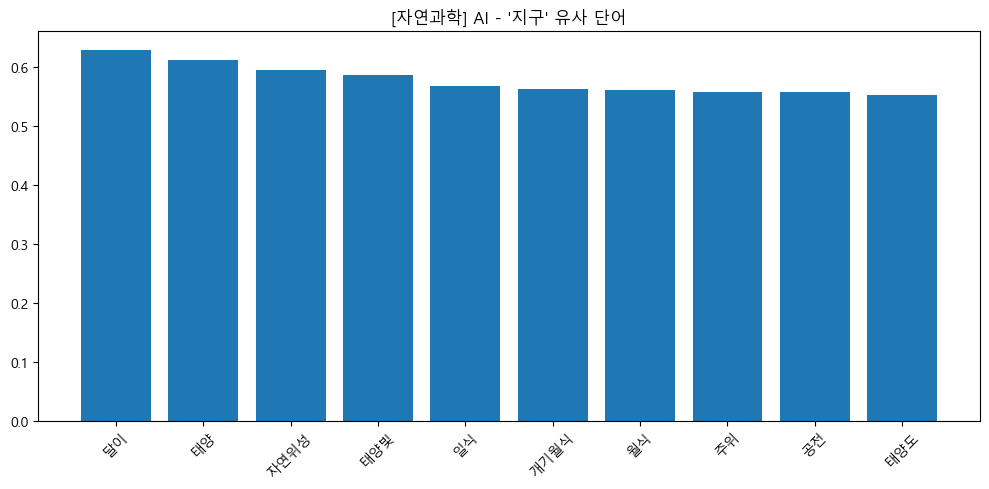

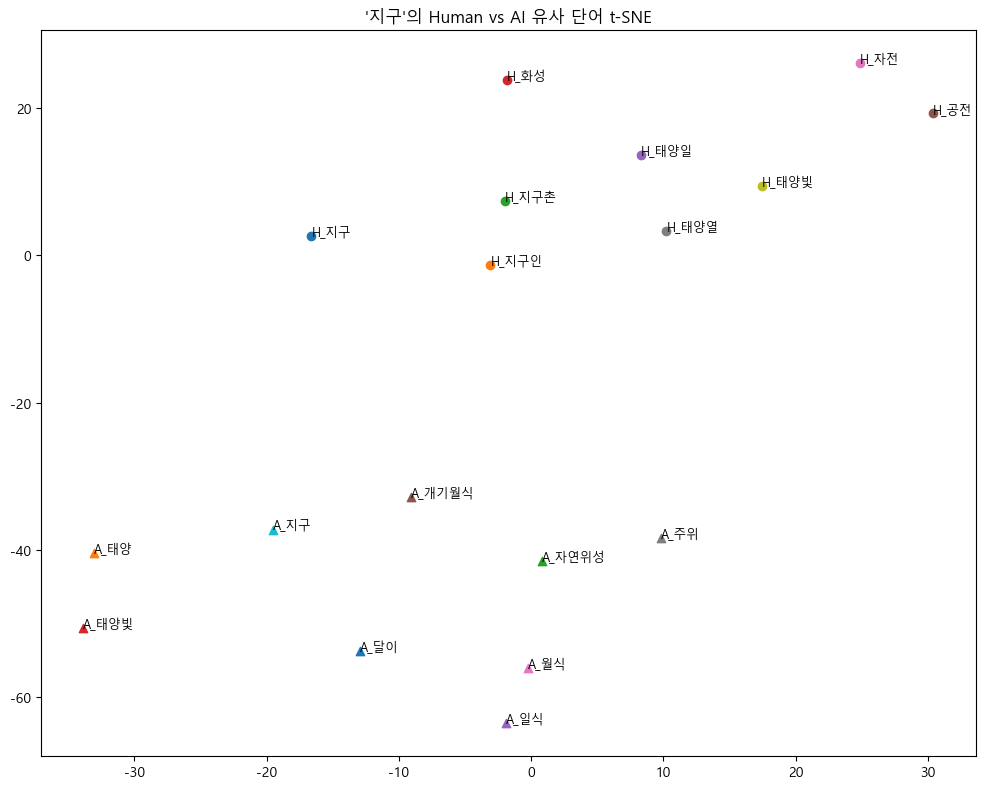


[주제] 천문학

[단어 존재 여부]


,word,in_human_vocab,in_ai_vocab,topic
0,우주,True,True,천문학
1,행성,True,True,천문학



[주제별 단어 빈도표]


,topic,word,human_count,ai_count,total_count
0,천문학,우주,963,1999,2962
1,천문학,행성,423,1502,1925


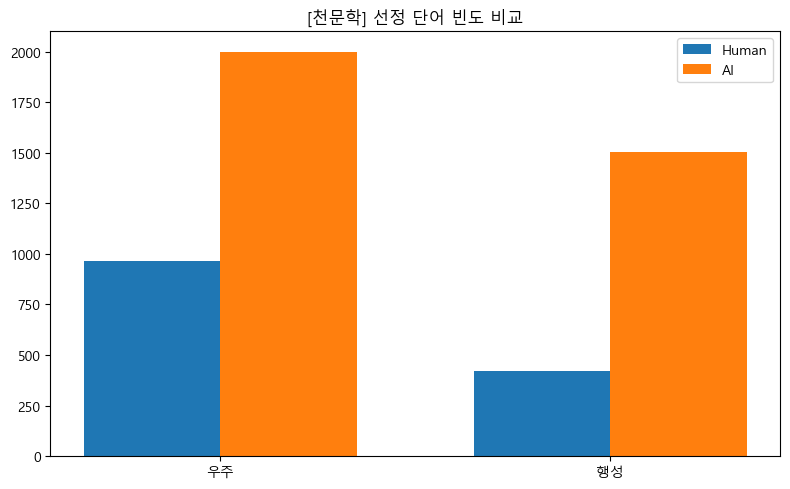


--- [천문학] '우주' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,천문학,우주,1,세트,0.809882,천문학,0.664099
1,천문학,우주,2,우주관,0.718854,관측,0.641903
2,천문학,우주,3,우주복,0.711603,빛점,0.612745
3,천문학,우주,4,우주상수,0.677467,기원,0.609627
4,천문학,우주,5,팽창,0.671962,모임,0.607529
5,천문학,우주,6,우주인,0.671172,천체,0.604592
6,천문학,우주,7,빅뱅,0.634643,전파천문학,0.588102
7,천문학,우주,8,우주론,0.634642,우주론,0.587250
8,천문학,우주,9,우주선,0.631978,밝혀내다,0.580955
9,천문학,우주,10,다중우주,0.616751,빅뱅,0.579955


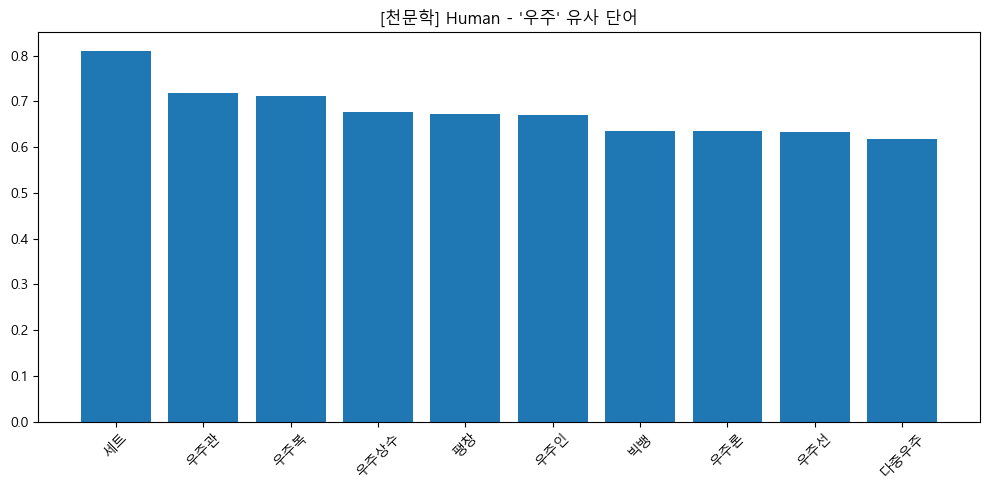

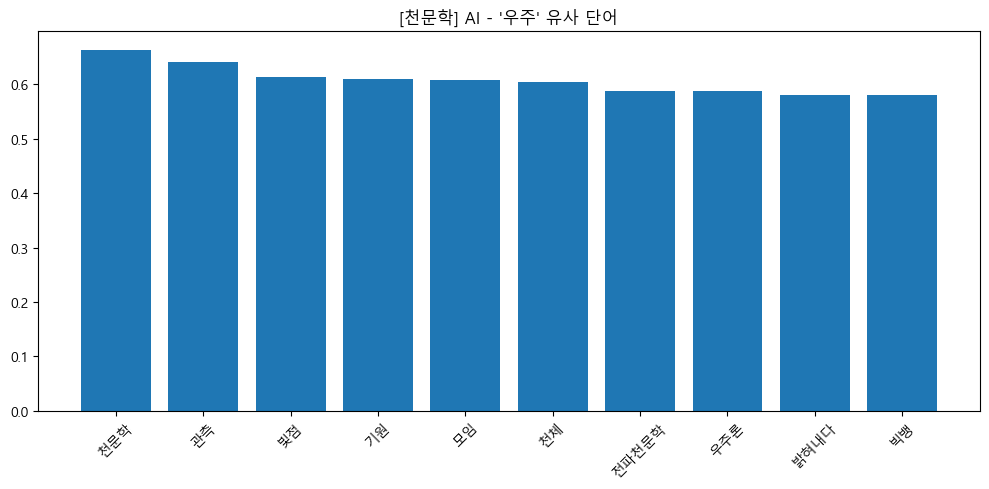

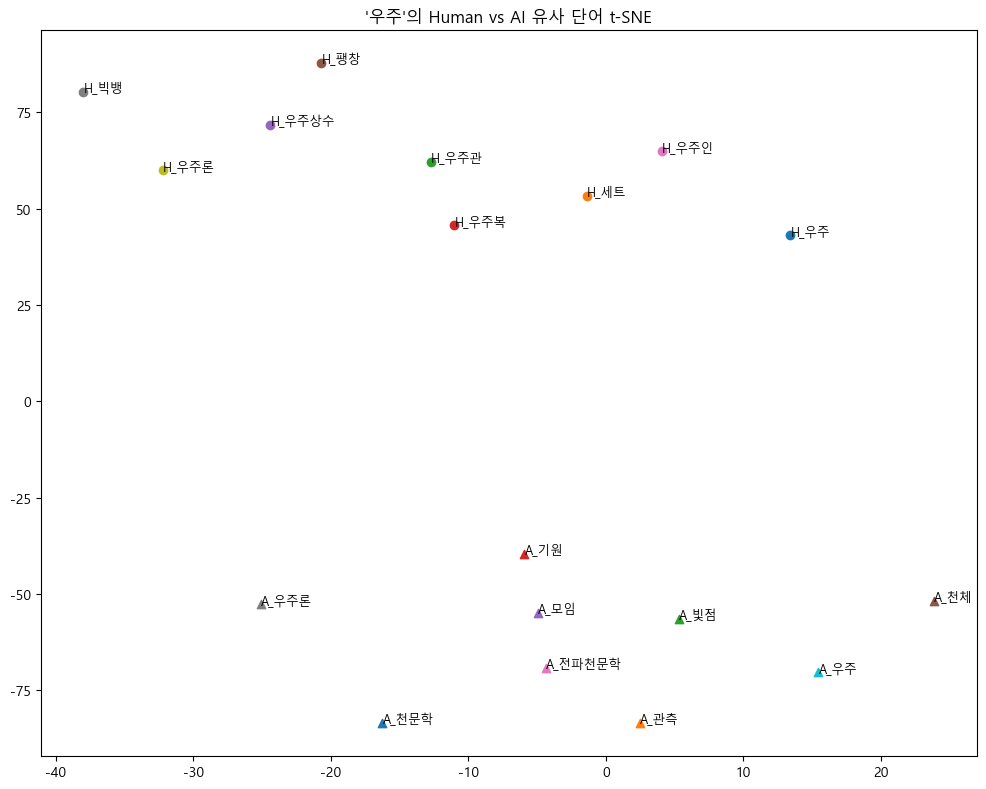


--- [천문학] '행성' 유사 단어 비교 ---


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,천문학,행성,1,내행성,0.829226,왜행성,0.733067
1,천문학,행성,2,태양계,0.826213,왜소행성,0.699689
2,천문학,행성,3,왜소행성,0.824553,내행성,0.688712
3,천문학,행성,4,소행성,0.821789,외행성,0.685722
4,천문학,행성,5,행성계,0.813507,항성,0.673291
5,천문학,행성,6,외행성,0.809363,행성계,0.664920
6,천문학,행성,7,목성,0.791961,천체,0.664280
7,천문학,행성,8,항성계,0.786947,항성계,0.656413
8,천문학,행성,9,외계행성,0.767133,소행성,0.642883
9,천문학,행성,10,해왕성,0.762622,외계행성,0.641622


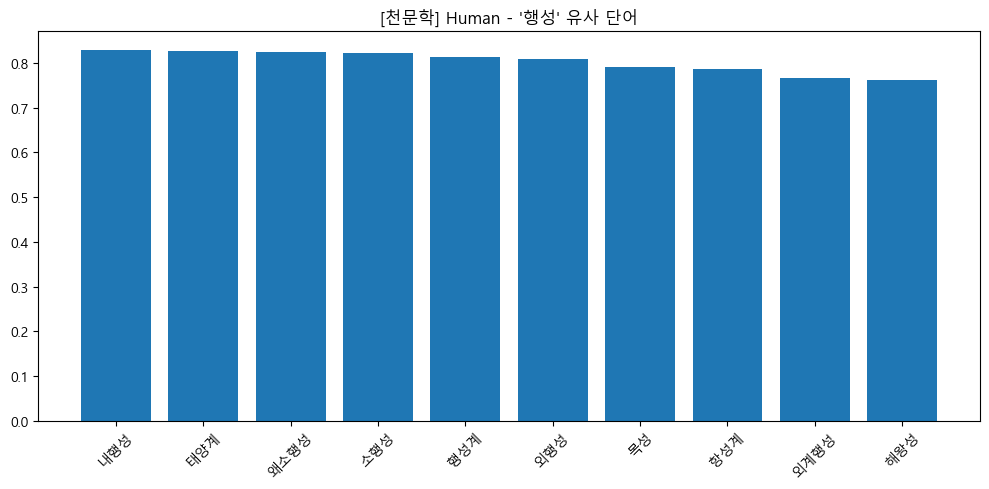

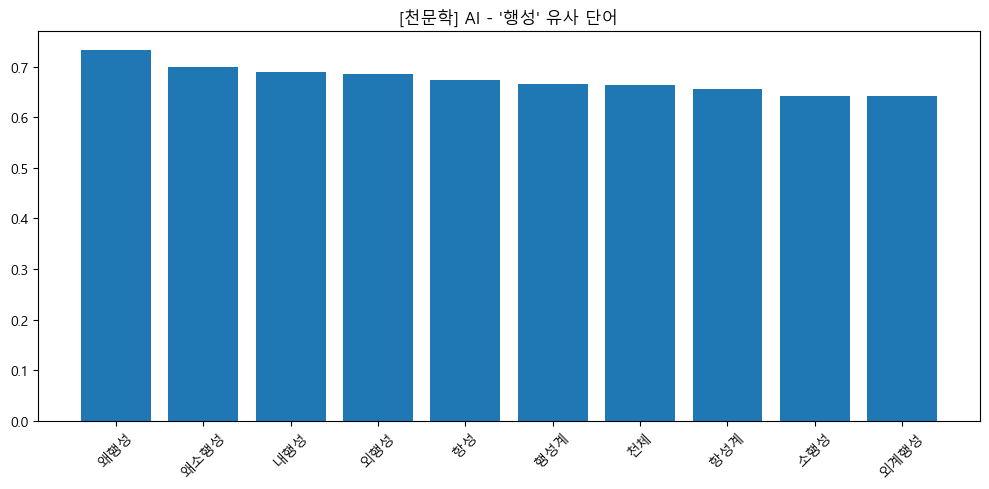

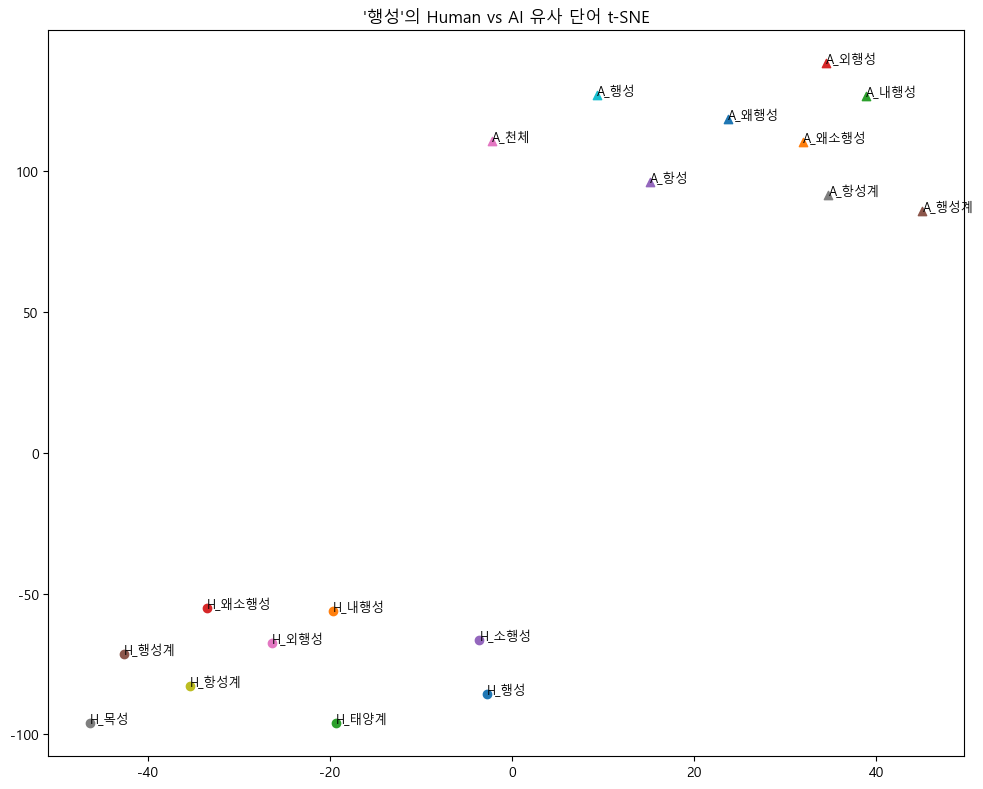


저장 완료:
- ../data/results/embedding/target_word_vocab_check.csv
- ../data/results/embedding/target_word_frequency_by_topic.csv
- ../data/results/embedding/target_word_similar_words_comparison.csv

[전체 단어 존재 여부 요약]


,word,in_human_vocab,in_ai_vocab,topic
0,기업,True,True,경제학
1,투자,True,True,경제학
2,행위,True,True,법률·법학
3,절차,True,True,법률·법학
4,학습,True,True,교육학
5,학생,True,True,교육학
6,에너지,True,True,자연과학
7,지구,True,True,자연과학
8,우주,True,True,천문학
9,행성,True,True,천문학



[전체 빈도표 요약]


,topic,word,human_count,ai_count,total_count
0,경제학,기업,444,1328,1772
1,경제학,투자,309,546,855
2,법률·법학,행위,575,637,1212
3,법률·법학,절차,297,898,1195
4,교육학,학습,351,3251,3602
5,교육학,학생,751,2792,3543
6,자연과학,에너지,221,1024,1245
7,자연과학,지구,360,521,881
8,천문학,우주,963,1999,2962
9,천문학,행성,423,1502,1925



[전체 유사 단어 비교표 일부]


,topic,target_word,rank,human_similar_word,human_similarity,ai_similar_word,ai_similarity
0,경제학,기업,1,대기업,0.733056,실적,0.611921
1,경제학,기업,2,기업인,0.696101,해외여행,0.605406
2,경제학,기업,3,기업가,0.694234,투자,0.578486
3,경제학,기업,4,기업체,0.684123,판매,0.570095
4,경제학,기업,5,공기업,0.678861,상품,0.568507
5,경제학,기업,6,중소기업,0.652299,수익,0.567299
6,경제학,기업,7,재무,0.638010,대기업,0.565191
7,경제학,기업,8,경영,0.637554,경쟁자,0.563950
8,경제학,기업,9,경쟁자,0.613733,시장,0.556331
9,경제학,기업,10,투자자,0.610374,신규,0.552766


In [40]:
# =========================================================
# 0. 라이브러리 import
# =========================================================
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from gensim.models import FastText
from sklearn.manifold import TSNE
from collections import Counter

# 한글 폰트 설정 (Windows)
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False


# =========================================================
# 1. 데이터 불러오기
# =========================================================
data_path = "../data/results/morph/morph_tokens.pkl"
data = pd.read_pickle(data_path)

print("데이터 크기:", data.shape)
print("컬럼 목록:", data.columns.tolist())
# display(data.head())


# =========================================================
# 2. pos_result 정리
# =========================================================
def ensure_pos_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                return ast.literal_eval(x)
            except:
                return []
    return []

data["pos_result"] = data["pos_result"].apply(ensure_pos_list)


# =========================================================
# 3. 내용어 기반 tokens_ft 재생성
#    - 명사 / 동사 / 형용사만 사용
# =========================================================
TARGET_TAGS = {"Noun", "Verb", "Adjective"}

stopwords = {
    "하다", "되다", "있다", "없다", "이다", "아니다",
    "것", "수", "들", "등", "더", "좀", "또", "그리고",
    "그러나", "하지만", "때문", "경우", "정도", "대한",
    "위해", "통해", "않다"
}

def extract_content_words(pos_result, min_len=2):
    results = []

    for item in pos_result:
        if not isinstance(item, (list, tuple)) or len(item) != 2:
            continue

        word, tag = item
        word = str(word).strip()

        if tag not in TARGET_TAGS:
            continue
        if not word:
            continue
        if len(word) < min_len:
            continue
        if word.isdigit():
            continue
        if word in stopwords:
            continue

        results.append(word)

    return results

data["tokens_ft"] = data["pos_result"].apply(extract_content_words)

print("\n[tokens_ft 예시]")
display(data[["topic_name", "source", "tokens_ft"]].head())


# =========================================================
# 4. 주제 컬럼 확인
# =========================================================
TOPIC_COL = "topic_name"

print("\n주제 목록:", data[TOPIC_COL].unique())


# =========================================================
# 5. 분석 대상 단어 정의
# =========================================================
TARGET_WORDS_BY_TOPIC = {
    "경제학": ["기업", "투자"],
    "법률·법학": ["행위", "절차"],
    "교육학": ["학습", "학생"],
    "자연과학": ["에너지", "지구"],
    "천문학": ["우주", "행성"]
}


# =========================================================
# 6. human / ai 데이터 분리
# =========================================================
human_df = data[data["source"] == "human"].copy()
ai_df = data[data["source"] == "ai"].copy()

human_sentences = [x for x in human_df["tokens_ft"].tolist() if len(x) > 0]
ai_sentences = [x for x in ai_df["tokens_ft"].tolist() if len(x) > 0]

print("\nHuman 문장 수:", len(human_sentences))
print("AI 문장 수:", len(ai_sentences))


# =========================================================
# 7. FastText 모델 학습
# =========================================================
human_ft = FastText(
    sentences=human_sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    epochs=10
)

ai_ft = FastText(
    sentences=ai_sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    epochs=10
)

print("\nHuman vocab size:", len(human_ft.wv))
print("AI vocab size:", len(ai_ft.wv))


# =========================================================
# 8. 모델 저장
# =========================================================
os.makedirs("../data/results/embedding", exist_ok=True)

human_ft.save("../data/results/embedding/human_fasttext.model")
ai_ft.save("../data/results/embedding/ai_fasttext.model")

print("\nFastText 모델 저장 완료")


# =========================================================
# 9. 단어 존재 여부 확인 함수
# =========================================================
def check_word_in_models(word, human_model, ai_model):
    return {
        "word": word,
        "in_human_vocab": word in human_model.wv.key_to_index,
        "in_ai_vocab": word in ai_model.wv.key_to_index
    }


# =========================================================
# 10. 주제별 단어 빈도 확인 함수
# =========================================================
def get_topic_word_counts(data, topic, words):
    topic_df = data[data[TOPIC_COL] == topic].copy()

    human_topic = topic_df[topic_df["source"] == "human"]
    ai_topic = topic_df[topic_df["source"] == "ai"]

    human_counter = Counter([t for s in human_topic["tokens_ft"] for t in s])
    ai_counter = Counter([t for s in ai_topic["tokens_ft"] for t in s])

    rows = []
    for word in words:
        rows.append({
            "topic": topic,
            "word": word,
            "human_count": human_counter[word],
            "ai_count": ai_counter[word],
            "total_count": human_counter[word] + ai_counter[word]
        })

    return pd.DataFrame(rows).sort_values("total_count", ascending=False)


# =========================================================
# 11. 유사 단어 비교표 생성 함수
# =========================================================
def get_similar_words_safe(word, model, topn=10):
    try:
        return model.wv.most_similar(word, topn=topn)
    except:
        return []

def make_similar_words_table(topic, word, human_model, ai_model, topn=10):
    human_sim = get_similar_words_safe(word, human_model, topn=topn)
    ai_sim = get_similar_words_safe(word, ai_model, topn=topn)

    rows = []
    max_len = max(len(human_sim), len(ai_sim))

    for i in range(max_len):
        h_word, h_score = human_sim[i] if i < len(human_sim) else ("", "")
        a_word, a_score = ai_sim[i] if i < len(ai_sim) else ("", "")

        rows.append({
            "topic": topic,
            "target_word": word,
            "rank": i + 1,
            "human_similar_word": h_word,
            "human_similarity": h_score,
            "ai_similar_word": a_word,
            "ai_similarity": a_score
        })

    return pd.DataFrame(rows)


# =========================================================
# 12. 빈도 비교 막대그래프
# =========================================================
def plot_topic_word_counts(freq_df, topic):
    if len(freq_df) == 0:
        return

    x = np.arange(len(freq_df))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, freq_df["human_count"], width=width, label="Human")
    plt.bar(x + width/2, freq_df["ai_count"], width=width, label="AI")

    plt.xticks(x, freq_df["word"], rotation=0)
    plt.title(f"[{topic}] 선정 단어 빈도 비교")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 13. 유사도 막대그래프
# =========================================================
def plot_similarity_bar(topic, word, human_model, ai_model, topn=10):
    human_sim = get_similar_words_safe(word, human_model, topn=topn)
    ai_sim = get_similar_words_safe(word, ai_model, topn=topn)

    if len(human_sim) == 0 and len(ai_sim) == 0:
        print(f"'{word}' 유사 단어가 없음")
        return

    # Human
    if len(human_sim) > 0:
        h_words = [w for w, _ in human_sim]
        h_scores = [s for _, s in human_sim]

        plt.figure(figsize=(10, 5))
        plt.bar(h_words, h_scores)
        plt.xticks(rotation=45)
        plt.title(f"[{topic}] Human - '{word}' 유사 단어")
        plt.tight_layout()
        plt.show()

    # AI
    if len(ai_sim) > 0:
        a_words = [w for w, _ in ai_sim]
        a_scores = [s for _, s in ai_sim]

        plt.figure(figsize=(10, 5))
        plt.bar(a_words, a_scores)
        plt.xticks(rotation=45)
        plt.title(f"[{topic}] AI - '{word}' 유사 단어")
        plt.tight_layout()
        plt.show()


# =========================================================
# 14. t-SNE 시각화
# =========================================================
def plot_tsne_compare(word, human_model, ai_model, topn=8):
    human_sim = get_similar_words_safe(word, human_model, topn=topn)
    ai_sim = get_similar_words_safe(word, ai_model, topn=topn)

    words = []
    vectors = []
    groups = []

    if word in human_model.wv.key_to_index:
        words.append(f"H_{word}")
        vectors.append(human_model.wv[word])
        groups.append("Human")

        for w, _ in human_sim:
            words.append(f"H_{w}")
            vectors.append(human_model.wv[w])
            groups.append("Human")

    if word in ai_model.wv.key_to_index:
        words.append(f"A_{word}")
        vectors.append(ai_model.wv[word])
        groups.append("AI")

        for w, _ in ai_sim:
            words.append(f"A_{w}")
            vectors.append(ai_model.wv[w])
            groups.append("AI")

    if len(vectors) < 3:
        print(f"'{word}' 시각화할 벡터가 부족함")
        return

    vectors = np.array(vectors)

    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=min(5, len(vectors)-1),
        init="random"
    )
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(10, 8))

    for i, group in enumerate(groups):
        if group == "Human":
            plt.scatter(reduced[i, 0], reduced[i, 1], marker="o")
        else:
            plt.scatter(reduced[i, 0], reduced[i, 1], marker="^")

        plt.text(reduced[i, 0], reduced[i, 1], words[i], fontsize=9)

    plt.title(f"'{word}'의 Human vs AI 유사 단어 t-SNE")
    plt.tight_layout()
    plt.show()


# =========================================================
# 15. 전체 분석 실행
# =========================================================
all_freq_tables = []
all_similar_tables = []
all_vocab_checks = []

for topic, words in TARGET_WORDS_BY_TOPIC.items():
    print("\n" + "="*90)
    print(f"[주제] {topic}")
    print("="*90)

    # 1) vocab 포함 여부 확인
    vocab_rows = []
    for word in words:
        row = check_word_in_models(word, human_ft, ai_ft)
        row["topic"] = topic
        vocab_rows.append(row)

    vocab_df = pd.DataFrame(vocab_rows)
    print("\n[단어 존재 여부]")
    display(vocab_df)
    all_vocab_checks.append(vocab_df)

    # 2) 빈도표
    freq_df = get_topic_word_counts(data, topic, words)
    print("\n[주제별 단어 빈도표]")
    display(freq_df)
    all_freq_tables.append(freq_df)

    # 3) 빈도 시각화
    plot_topic_word_counts(freq_df, topic)

    # 4) 유사 단어 비교표 + 시각화
    for word in words:
        print(f"\n--- [{topic}] '{word}' 유사 단어 비교 ---")

        sim_df = make_similar_words_table(topic, word, human_ft, ai_ft, topn=10)
        display(sim_df)
        all_similar_tables.append(sim_df)

        plot_similarity_bar(topic, word, human_ft, ai_ft, topn=10)
        plot_tsne_compare(word, human_ft, ai_ft, topn=8)


# =========================================================
# 16. 전체 결과 저장
# =========================================================
vocab_check_result = pd.concat(all_vocab_checks, ignore_index=True)
freq_result = pd.concat(all_freq_tables, ignore_index=True)
similar_result = pd.concat(all_similar_tables, ignore_index=True)

vocab_check_result.to_csv(
    "../data/results/embedding/target_word_vocab_check.csv",
    index=False,
    encoding="utf-8-sig"
)

freq_result.to_csv(
    "../data/results/embedding/target_word_frequency_by_topic.csv",
    index=False,
    encoding="utf-8-sig"
)

similar_result.to_csv(
    "../data/results/embedding/target_word_similar_words_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n저장 완료:")
print("- ../data/results/embedding/target_word_vocab_check.csv")
print("- ../data/results/embedding/target_word_frequency_by_topic.csv")
print("- ../data/results/embedding/target_word_similar_words_comparison.csv")


# =========================================================
# 17. 전체 요약 출력
# =========================================================
print("\n[전체 단어 존재 여부 요약]")
display(vocab_check_result)

print("\n[전체 빈도표 요약]")
display(freq_result)

print("\n[전체 유사 단어 비교표 일부]")
display(similar_result.head(30))

In [41]:
def plot_tsne_two_words(word1, word2, human_model, ai_model, topn=8):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for idx, word in enumerate([word1, word2]):
        ax = axes[idx]

        human_sim = get_similar_words_safe(word, human_model, topn=topn)
        ai_sim = get_similar_words_safe(word, ai_model, topn=topn)

        words = []
        vectors = []
        groups = []

        # Human
        if word in human_model.wv:
            words.append(f"H_{word}")
            vectors.append(human_model.wv[word])
            groups.append("Human")

            for w, _ in human_sim:
                words.append(f"H_{w}")
                vectors.append(human_model.wv[w])
                groups.append("Human")

        # AI
        if word in ai_model.wv:
            words.append(f"A_{word}")
            vectors.append(ai_model.wv[word])
            groups.append("AI")

            for w, _ in ai_sim:
                words.append(f"A_{w}")
                vectors.append(ai_model.wv[w])
                groups.append("AI")

        vectors = np.array(vectors)

        tsne = TSNE(
            n_components=2,
            random_state=42,
            perplexity=min(5, len(vectors)-1),
            init="random"
        )

        reduced = tsne.fit_transform(vectors)

        for i, group in enumerate(groups):
            if group == "Human":
                ax.scatter(reduced[i, 0], reduced[i, 1], marker="o")
            else:
                ax.scatter(reduced[i, 0], reduced[i, 1], marker="^")

            ax.text(reduced[i, 0], reduced[i, 1], words[i], fontsize=9)

        ax.set_title(f"'{word}'")

    plt.suptitle("Human vs AI t-SNE Comparison")
    plt.tight_layout()
    plt.show()

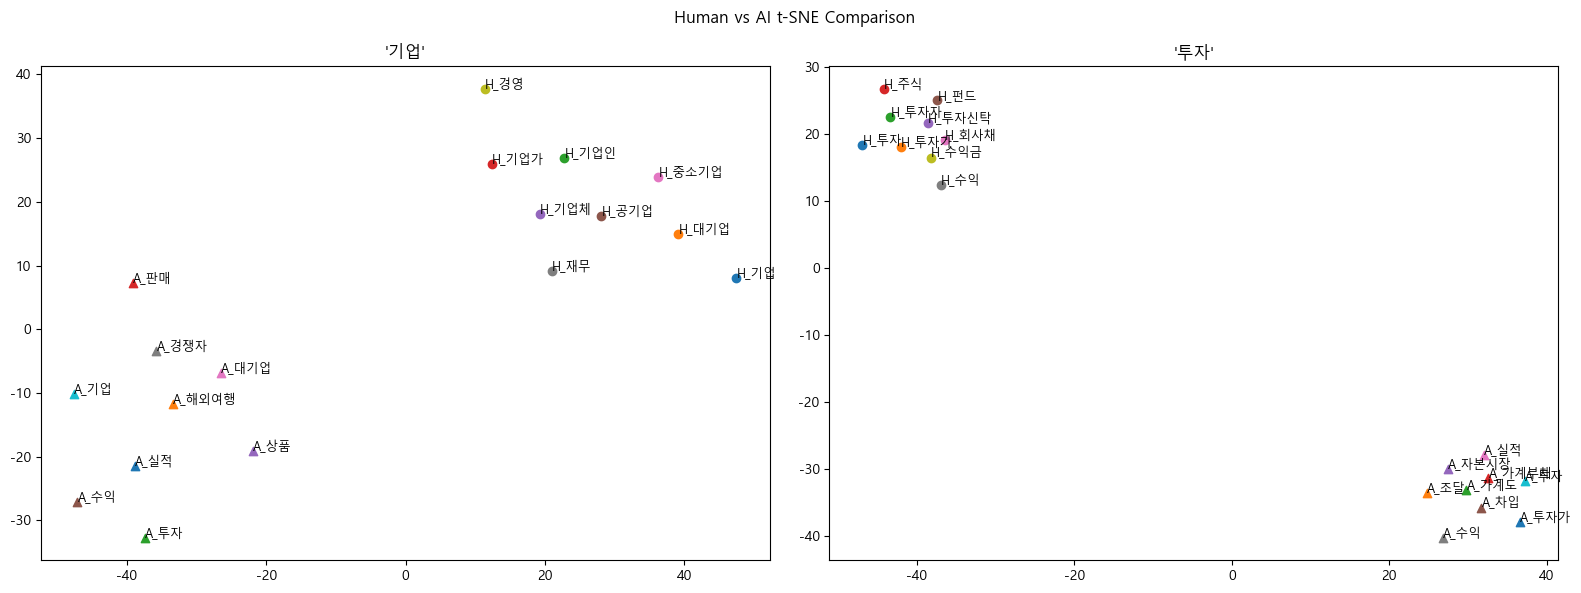

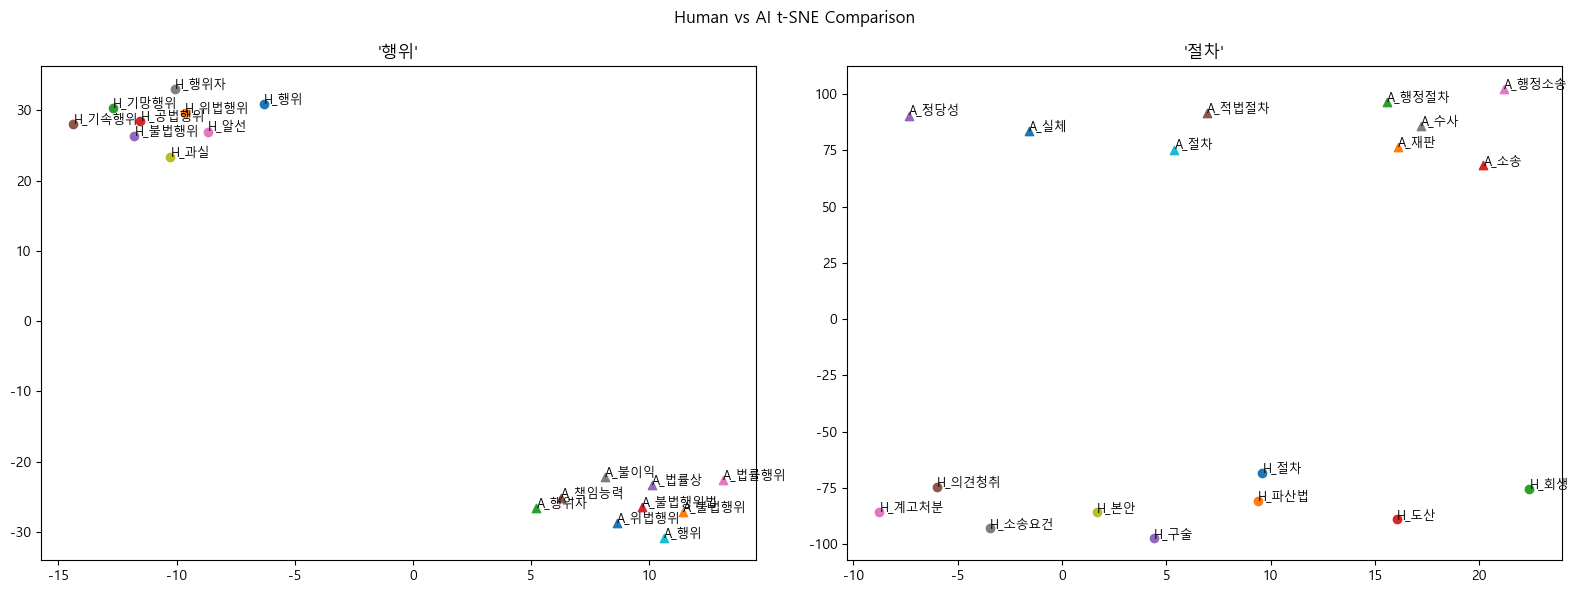

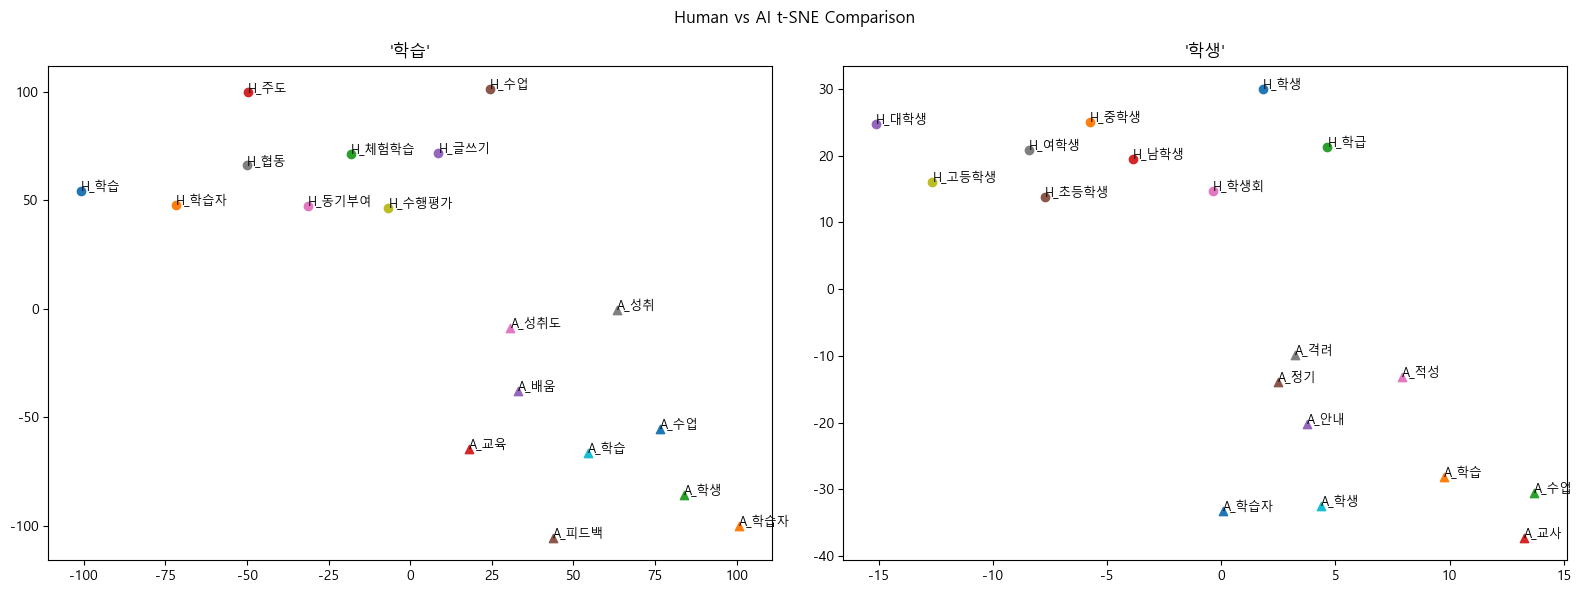

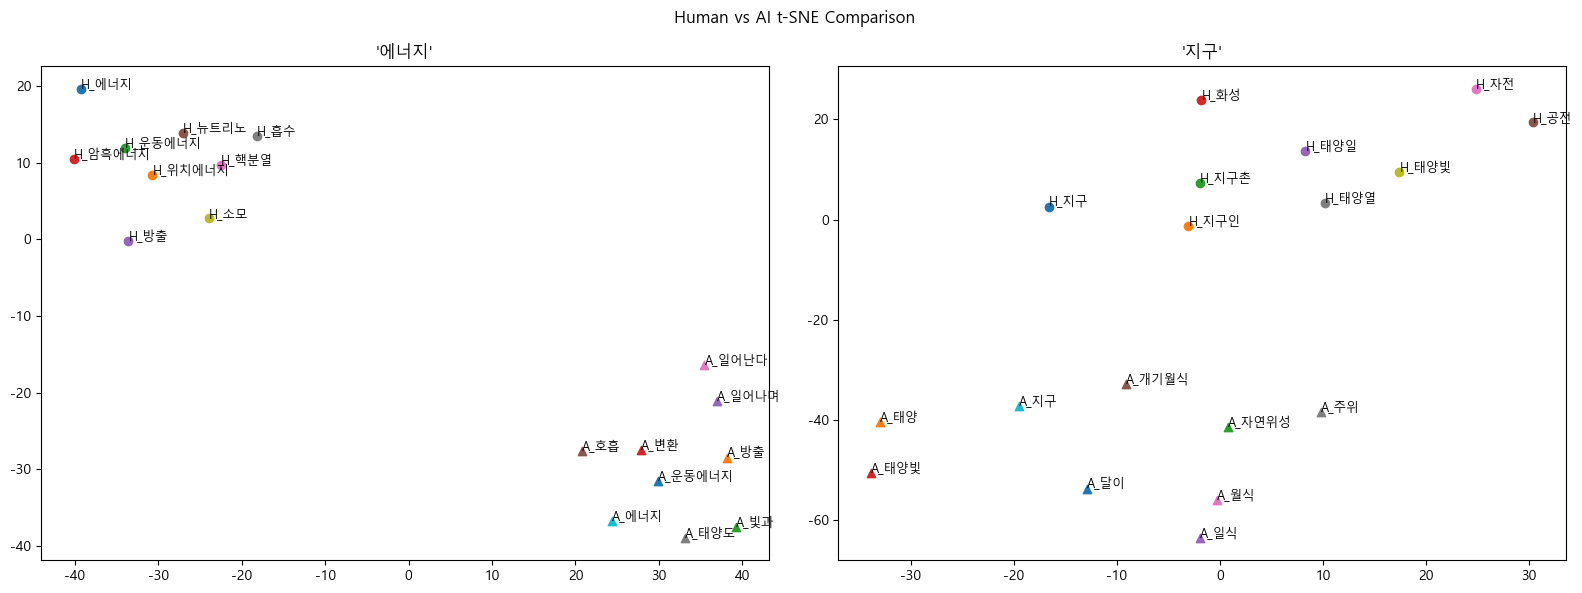

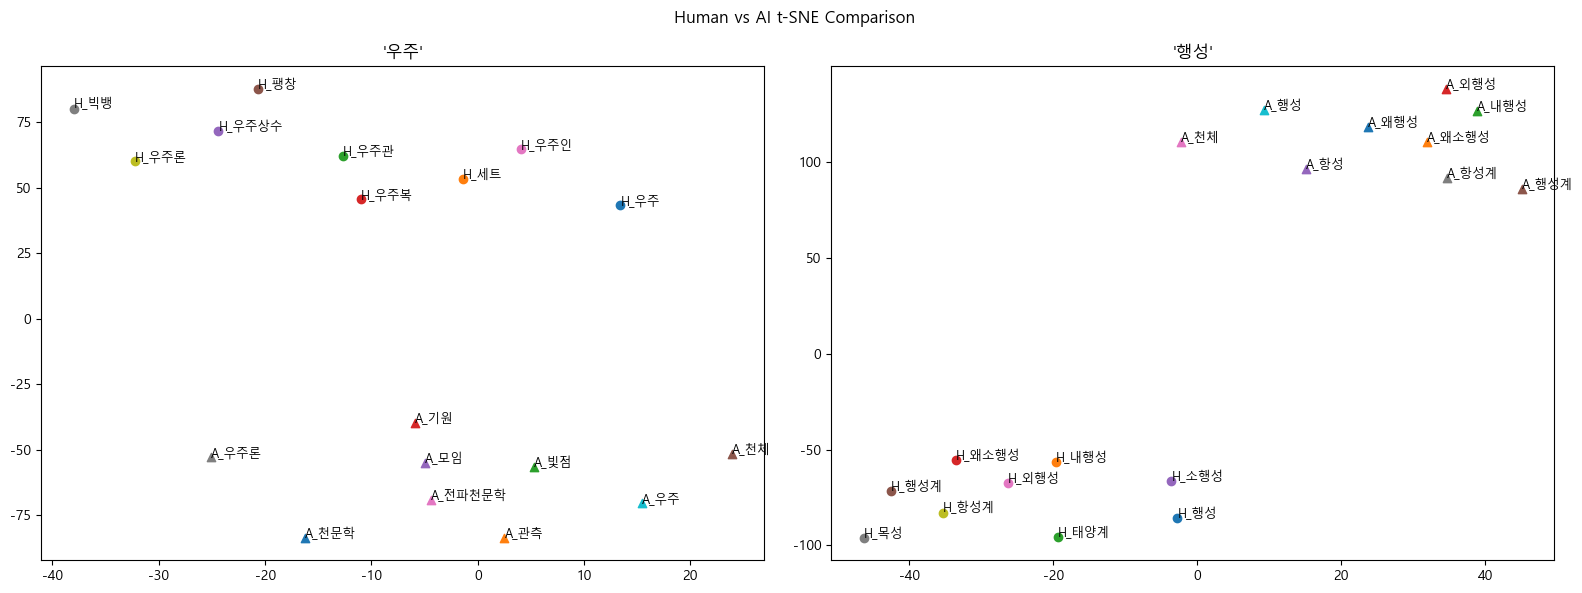

In [48]:
plot_tsne_two_words("기업", "투자", human_ft, ai_ft)
plot_tsne_two_words("행위", "절차", human_ft, ai_ft)
plot_tsne_two_words("학습", "학생", human_ft, ai_ft)
plot_tsne_two_words("에너지", "지구", human_ft, ai_ft)
plot_tsne_two_words("우주", "행성", human_ft, ai_ft)

# 정리

### 형태소 분석 결과
- source별 전체 토큰 수
- source별 고유 토큰 수
- source별 문장당 평균 토큰 수
- source별 품사 비율 표
- source별 고빈도 명사 top 20
- topic별 고빈도 명사 비교
- AI와 human 간 상대적으로 과다 사용되는 명사/형용사/동사


### 문장 임베딩 결과
- 문장 임베딩 행렬
- source별 평균 벡터 비교
- UMAP/t-SNE 시각화
- topic별 임베딩 군집 분포
- human/ai 분류 모델 입력 feature로 활용 가능